<a href="https://colab.research.google.com/github/JESUSJEREZ/Trabajo-de-Grado_Hotel_Portoalegre/blob/main/Trabajo_de_Grado_Segmentacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo de Segmentación de Clientes

Para las bases df_reservas_dep y df_temporalidad

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import silhouette_score

In [ ]:
# ============================================================
# 1. CARGA Y PREPARACIÓN DE DATOS
# ============================================================

# Para clonar un repositorio de GitHub
# Reemplaza 'TU_URL_DEL_REPOSITORIO' con la URL real de tu repositorio.
!git clone https://github.com/JESUSJEREZ/Trabajo-de-Grado_Hotel_Portoalegre.git

print("https://github.com/JESUSJEREZ/Trabajo-de-Grado_Hotel_Portoalegre.git")

fatal: destination path 'Trabajo-de-Grado_Hotel_Portoalegre' already exists and is not an empty directory.
https://github.com/JESUSJEREZ/Trabajo-de-Grado_Hotel_Portoalegre.git


In [ ]:
# Read df_reservas_dep

github_raw_url = 'https://raw.githubusercontent.com/JESUSJEREZ/Trabajo-de-Grado_Hotel_Portoalegre/main/df_reservas_dep.xlsx'

try:
    df_res = pd.read_excel(github_raw_url)
    print(f"✔ Archivo cargado desde GitHub: {github_raw_url} | Filas: {len(df_res)}")
    display(df_res.head())
except Exception as e:
    print(f"❌ Error al intentar leer el archivo desde GitHub: {e}")

✔ Archivo cargado desde GitHub: https://raw.githubusercontent.com/JESUSJEREZ/Trabajo-de-Grado_Hotel_Portoalegre/main/df_reservas_dep.xlsx | Filas: 25151


,id_reserva,fecha_ingreso,fecha_salida,numero_personas,nombre_cuarto,id_grupo,agencia,nombre,primer_apellido,segundo_apellido,...,transferencia_bancaria_distribuido,wompi_distribuido,nequi_distribuido,corresponsal_bancario_distribuido,pse_distribuido,boton_pagos_bancolombia_distribuido,retefuente_distribuido,cta_por_cobrar_propietario_distribuido,cta_por_cobrar_compania_distribuido,abonos_distribuido
0,6816119,2023-01-01,2023-01-02,4,Cuadruple 37,NaN,Venta Directa x Vendedor,Deisy Paola,Ballesteros,Reyes,...,232000.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,6816120,2023-01-01,2023-01-02,4,Cuadruple 38,NaN,Venta Directa x Vendedor,Deisy Paola,Ballesteros,Reyes,...,232000.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,7053733,2023-01-01,2023-01-20,1,Doble 39,NaN,NaN,Yenny,Restrepo,NaN,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,6816121,2023-01-01,2023-01-02,2,Doble 87,NaN,Booking Engine,Maira,Giraldo,Garcia,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,7066729,2023-01-01,2023-01-04,5,Familiar 86,NaN,Venta pag web,Paola Andrea,Ordoñes,García,...,333333.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Read df_temporalidad

github_raw_url_temp = 'https://raw.githubusercontent.com/JESUSJEREZ/Trabajo-de-Grado_Hotel_Portoalegre/main/df_temporalidad.xlsx'

try:
    df_temp = pd.read_excel(github_raw_url_temp)
    print(f"✔ Archivo cargado desde GitHub (nueva carga): {github_raw_url_temp} | Filas: {len(df_temp)}")
    display(df_temp.head())
except Exception as e:
    print(f"❌ Error al intentar leer el archivo desde GitHub: {e}")

✔ Archivo cargado desde GitHub (nueva carga): https://raw.githubusercontent.com/JESUSJEREZ/Trabajo-de-Grado_Hotel_Portoalegre/main/df_temporalidad.xlsx | Filas: 1058


,fecha_noche,personas,ingresos,cuartos_ocupados,ingreso_por_huesped,ingreso_por_cuarto,ocupacion,precipitacion_mm,sol_horas,temporada,...,ocupacion_lag1,ocupacion_lag7,ingresos_lag1,ingresos_lag7,ocupacion_ma7,ingresos_ma7,dow_sin,dow_cos,mes_sin,mes_cos
0,2023-02-08,64,6.603937e+06,26,103186.513802,253997.572436,0.438356,0.0,11.195083,Baja,...,0.465753,0.301370,6.688893e+06,4.416740e+06,0.528376,7.493013e+06,0.974928,-0.222521,0.866025,0.5
1,2023-02-09,48,4.925649e+06,20,102617.681597,246282.435833,0.328767,0.0,11.192797,Baja,...,0.438356,0.369863,6.603937e+06,5.598111e+06,0.547945,7.805470e+06,0.433884,-0.900969,0.866025,0.5
2,2023-02-10,44,4.212566e+06,15,95740.135606,280837.731111,0.301370,0.0,11.257283,Baja,...,0.328767,0.636986,4.925649e+06,8.838389e+06,0.542074,7.709404e+06,-0.433884,-0.900969,0.866025,0.5
3,2023-02-11,39,4.132927e+06,16,105972.482295,258307.925595,0.267123,0.0,11.187792,Baja,...,0.301370,0.821918,4.212566e+06,1.134276e+07,0.494129,7.048572e+06,-0.974928,-0.222521,0.866025,0.5
4,2023-02-12,23,2.212260e+06,9,96185.223602,245806.682540,0.157534,0.2,11.251803,Baja,...,0.267123,0.458904,4.132927e+06,6.788844e+06,0.414873,6.018595e+06,-0.781831,0.623490,0.866025,0.5


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ══════════════════════════════════════════════════════════════════
# 2. ANÁLISIS EXPLORATORIO — RESERVAS
# ══════════════════════════════════════════════════════════════════n

print("\n" + "═"*60)
print("  2. EDA — RESERVAS")
print("═"*60)

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Análisis Exploratorio — Reservas", fontsize=16, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── 2a. Ingresos por año ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ing_año = df_res.groupby("Año")["ingreso_distribuido"].sum() / 1e9
bars = ax1.bar(ing_año.index.astype(str), ing_año.values,
               color=["#2E6DA4","#1B3A5C","#C9A84C","#82B366"])
ax1.set_title("Ingresos totales por año (COP miles MM)")
ax1.set_ylabel("Miles de millones COP")
for b in bars:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
             f"${b.get_height():.1f}B", ha="center", va="bottom", fontsize=8)

# ── 2b. Distribución días estadía ────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
dias = df_res.drop_duplicates("id_reserva")["dias_estadia"].clip(0, 15)
ax2.hist(dias, bins=range(0, 16), color="#2E6DA4", edgecolor="white", linewidth=0.8)
ax2.set_title("Distribución de días de estadía")
ax2.set_xlabel("Noches")
ax2.set_ylabel("Reservas")
ax2.axvline(dias.mean(), color="#C0392B", linestyle="--", linewidth=1.5,
            label=f"Media: {dias.mean():.1f}n")
ax2.legend(fontsize=8)

# ── 2c. Categorías de habitación ─────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
cat_counts = df_res.drop_duplicates("id_reserva")["nombre_categoria"].value_counts()
colors_cat = plt.cm.Blues_r(np.linspace(0.2, 0.85, len(cat_counts)))
wedges, texts, autotexts = ax3.pie(
    cat_counts.values, labels=None,
    autopct=lambda p: f"{p:.0f}%" if p > 4 else "",
    colors=colors_cat, startangle=140,
    wedgeprops={"linewidth": 0.6, "edgecolor": "white"})
for at in autotexts:
    at.set_fontsize(7)
ax3.set_title("Categoría de habitación")
ax3.legend(cat_counts.index, loc="lower center", bbox_to_anchor=(0.5, -0.28),
           ncol=2, fontsize=7, frameon=False)

# ── 2d. Canal de reserva ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
def clasif_canal(a):
    if pd.isna(a): return "Directo"
    a = str(a).lower()
    if "booking" in a or "engine" in a: return "OTA/Online"
    if any(x in a for x in ["agencia","vendedor","comercial","sandra","libardo"]):
        return "Agencia/Vendedor"
    if "whatsapp" in a or "puerta" in a: return "Directo"
    if "portoalegre" in a or a.strip()=="17": return "Propiedad"
    return "Directo"

res_uni = df_res.drop_duplicates("id_reserva").copy()
res_uni["canal"] = res_uni["agencia"].apply(clasif_canal)
canal_counts = res_uni["canal"].value_counts()
canal_colors = ["#1B3A5C","#2E6DA4","#C9A84C","#82B366"]
bars4 = ax4.barh(canal_counts.index, canal_counts.values,
                 color=canal_colors[:len(canal_counts)])
ax4.set_title("Canal de reserva")
for b in bars4:
    ax4.text(b.get_width() + 30, b.get_y() + b.get_height()/2,
             f"{b.get_width():,.0f}", va="center", fontsize=8)
ax4.set_xlabel("Reservas")

# ── 2e. Ingresos por noche (distribución) ────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ingresos_res = res_uni["ingreso_distribuido"] \
    .apply(lambda _: df_res.groupby("id_reserva")["ingreso_distribuido"] \
    .sum()[res_uni["id_reserva"]].values \
    if False else None)  # placeholder
ing_por_res = df_res.groupby("id_reserva")["ingreso_distribuido"].sum()
ing_por_res_clip = ing_por_res.clip(0, 5e6)
ax5.hist(ing_por_res_clip / 1e3, bins=40, color="#5A4E9E", edgecolor="white", linewidth=0.5)
ax5.set_title("Distribución ingreso por reserva (miles COP)")
ax5.set_xlabel("Miles COP")
ax5.set_ylabel("Reservas")
med = ing_por_res.median() / 1e3
ax5.axvline(min(med, 5000), color="#C0392B", linestyle="--", linewidth=1.5,
            label=f"Mediana: ${med:,.0f}K")
ax5.legend(fontsize=8)

# ── 2f. Número de personas ────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
pers = res_uni["numero_personas"].clip(1, 10).value_counts().sort_index()
ax6.bar(pers.index.astype(str), pers.values, color="#2E8B7A", edgecolor="white")
ax6.set_title("Personas por reserva")
ax6.set_xlabel("Personas")
ax6.set_ylabel("Reservas")

# ── 2g. Nulos por columna clave ───────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0])
cols_nulos = ["id_grupo","agencia","email","Identificacion","Nacionalidad",
              "primer_apellido","segundo_apellido","Tipo doc"]
nulos = df_res[cols_nulos].isnull().sum()
nulos_pct = (nulos / len(df_res) * 100).sort_values(ascending=True)
bars7 = ax7.barh(nulos_pct.index, nulos_pct.values,
                 color=["#C0392B" if v > 10 else "#F0B27A" if v > 2 else "#82B366"
                        for v in nulos_pct.values])
ax7.set_title("Completitud de campos clave (%  nulos)")
ax7.set_xlabel("% nulos")
for b in bars7:
    if b.get_width() > 0:
        ax7.text(b.get_width() + 0.3, b.get_y() + b.get_height()/2,
                 f"{b.get_width():.1f}%", va="center", fontsize=8)

# ── 2h. Reservas por mes ─────────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 1:])
df_res["mes_año"] = pd.to_datetime(df_res["fecha_ingreso"]).dt.to_period("M")
mes_res = df_res.drop_duplicates("id_reserva").groupby("mes_año").size()
mes_res.index = mes_res.index.astype(str)
ax8.plot(range(len(mes_res)), mes_res.values, color="#2E6DA4", linewidth=2)
ax8.fill_between(range(len(mes_res)), mes_res.values, alpha=0.15, color="#2E6DA4")
ax8.set_title("Reservas por mes (serie temporal)")
ax8.set_xticks(range(0, len(mes_res), 3))
ax8.set_xticklabels(list(mes_res.index)[::3], rotation=45, ha="right", fontsize=8)
ax8.set_ylabel("Reservas")
ax8.grid(axis="y", alpha=0.3)

plt.savefig("01_eda_reservas.png")
plt.close()
print("  ✓ 01_eda_reservas.png")


════════════════════════════════════════════════════════════
  2. EDA — RESERVAS
════════════════════════════════════════════════════════════
  ✓ 01_eda_reservas.png


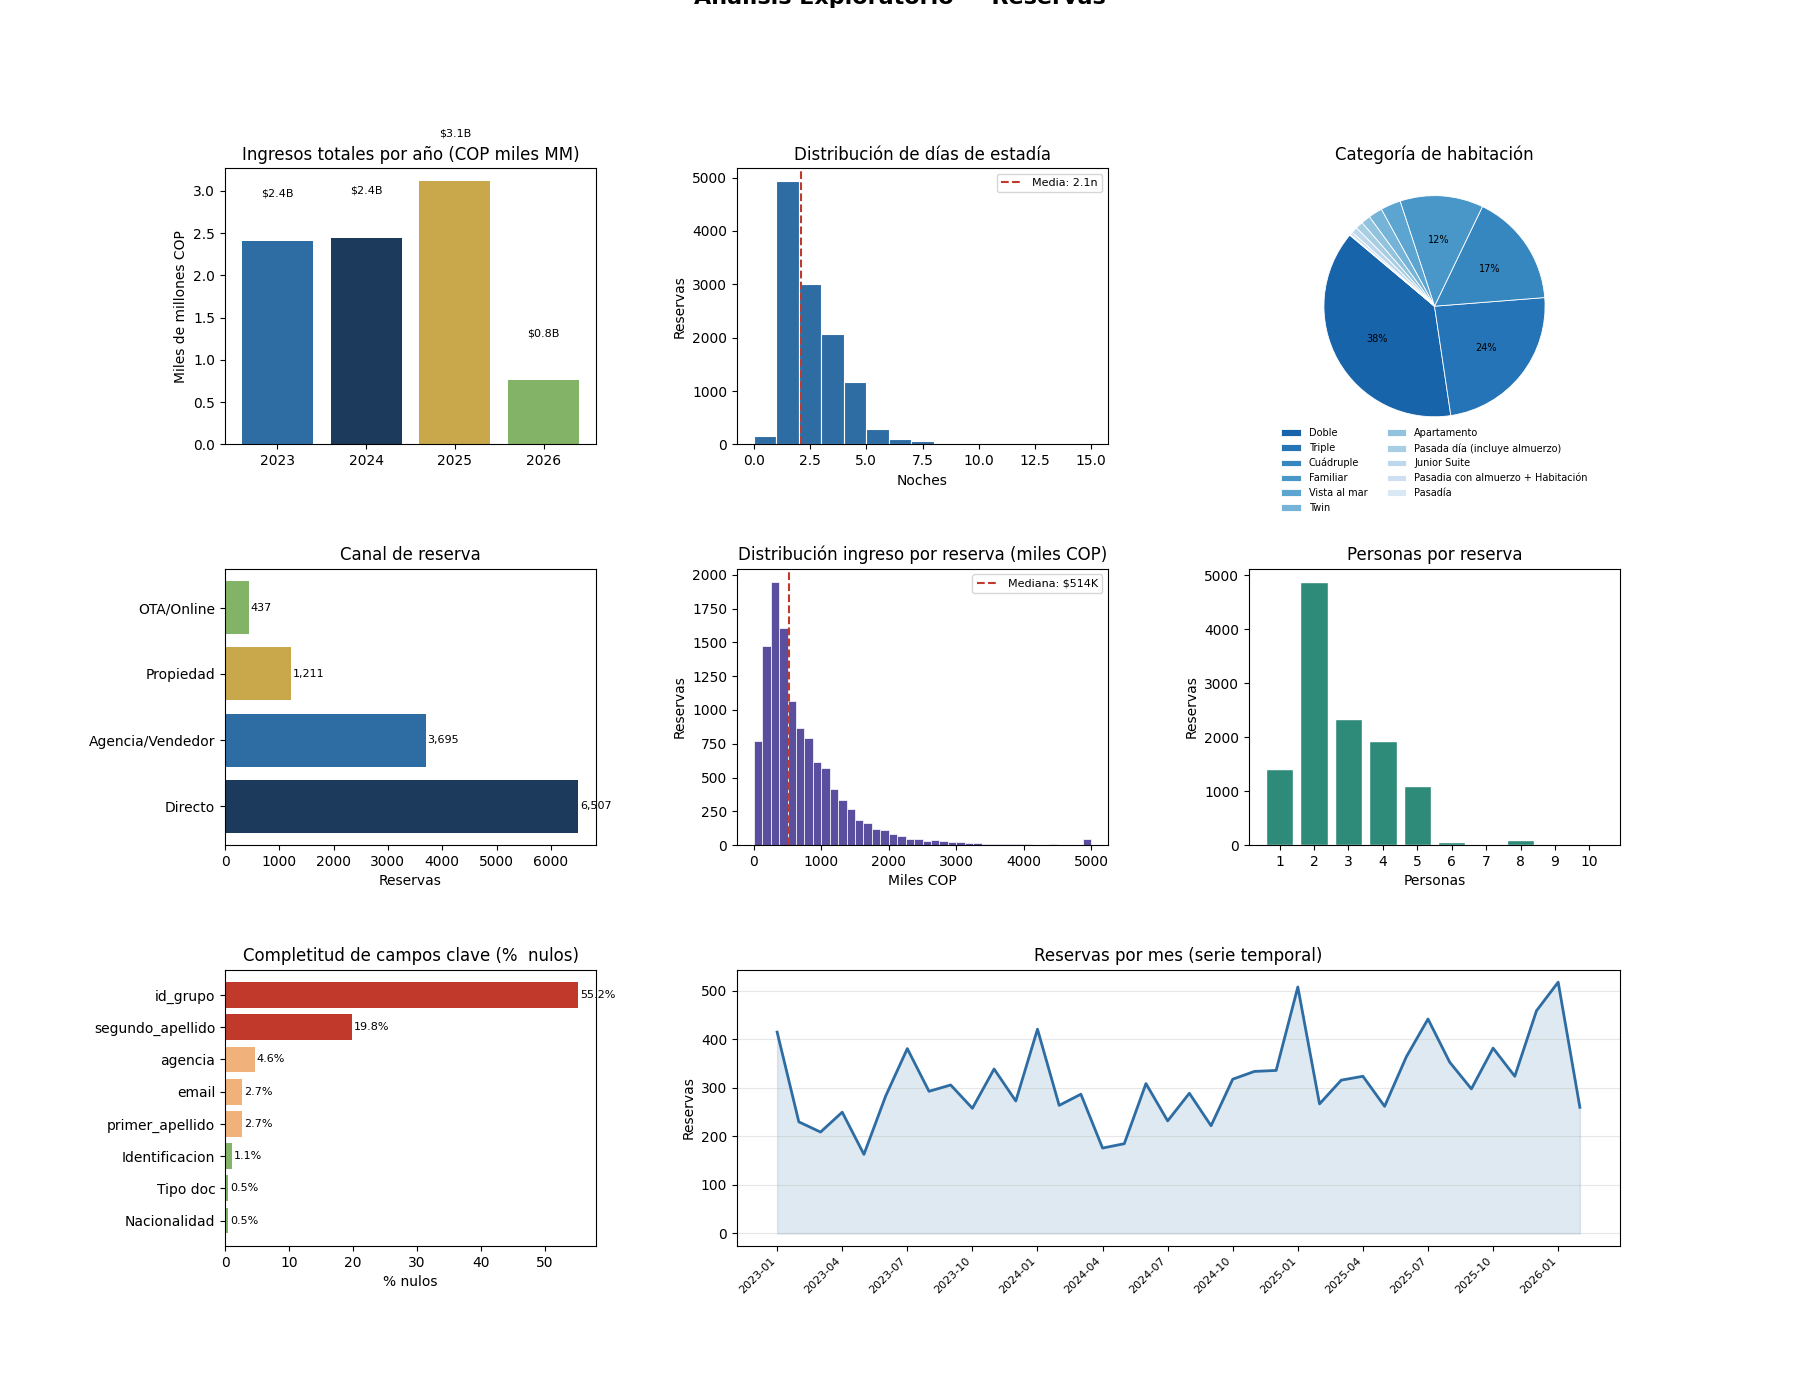

In [ ]:
from IPython.display import Image
Image('01_eda_reservas.png')

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

# Define the color palette for seasons
TEMPORADA_PAL = {
    "Baja": "#82B366",    # Greenish
    "Media": "#C9A84C",   # Yellowish
    "Alta": "#C0392B"     # Reddish
}

# ══════════════════════════════════════════════════════════════════
# 3. ANÁLISIS EXPLORATORIO — TEMPORALIDAD
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("  3. EDA — TEMPORALIDAD")
print("═"*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Análisis Exploratorio — Temporalidad", fontsize=16, fontweight="bold")
plt.subplots_adjust(hspace=0.4, wspace=0.35)

# ── 3a. Ocupación por temporada ───────────────────────────────────
ax = axes[0, 0]
for temp, grp in df_temp.groupby("temporada"):
    ax.hist(grp["ocupacion"], bins=25, alpha=0.65,
            color=TEMPORADA_PAL[temp], label=temp, edgecolor="white", linewidth=0.4)
ax.set_title("Distribución de ocupación por temporada")
ax.set_xlabel("Ocupación")
ax.set_ylabel("Días")
ax.legend(fontsize=9)

# ── 3b. Ingresos por temporada ───────────────────────────────────
ax = axes[0, 1]
temp_order = ["Baja","Media","Alta"]
data_box = [df_temp[df_temp["temporada"]==t]["ingresos"].values / 1e6
            for t in temp_order]
bp = ax.boxplot(data_box, patch_artist=True, tick_labels=temp_order,
                medianprops={"color":"white","linewidth":2})
for patch, temp in zip(bp["boxes"], temp_order):
    patch.set_facecolor(TEMPORADA_PAL[temp])
    patch.set_alpha(0.85)
ax.set_title("Ingresos por temporada (millones COP)")
ax.set_ylabel("Millones COP")

# ── 3c. Ocupación a lo largo del año ─────────────────────────────
ax = axes[0, 2]
df_temp["fecha_noche"] = pd.to_datetime(df_temp["fecha_noche"])
df_temp_sorted = df_temp.sort_values("fecha_noche")
ax.plot(df_temp_sorted["fecha_noche"], df_temp_sorted["ocupacion_ma7"],
        color="#2E6DA4", linewidth=1.5, label="Media móvil 7d")
ax.scatter(df_temp_sorted["fecha_noche"], df_temp_sorted["ocupacion"],
           c=[TEMPORADA_PAL[t] for t in df_temp_sorted["temporada"]],
           alpha=0.25, s=8)
ax.set_title("Ocupación en el tiempo")
ax.set_ylabel("Ocupación")
handles = [mpatches.Patch(color=c, label=t) for t, c in TEMPORADA_PAL.items()]
ax.legend(handles=handles, fontsize=8, loc="upper left")
ax.tick_params(axis="x", rotation=30)

# ── 3d. Sol vs Precipitación vs Temporada ────────────────────────
ax = axes[1, 0]
for temp, grp in df_temp.groupby("temporada"):
    ax.scatter(grp["precipitacion_mm"], grp["sol_horas"],
               color=TEMPORADA_PAL[temp], alpha=0.55, s=25, label=temp,
               edgecolors="none")
ax.set_title("Sol vs. Precipitación por temporada")
ax.set_xlabel("Precipitación (mm)")
ax.set_ylabel("Horas de sol")
ax.legend(fontsize=9)

# ── 3e. Fin de semana vs. Entre semana ───────────────────────────
ax = axes[1, 1]
fin_comp = df_temp.groupby("fin_semana").agg(
    ocupacion=("ocupacion","mean"),
    ingresos=("ingresos","mean")
).reset_index()
fin_comp["tipo"] = fin_comp["fin_semana"].map({0:"Entre semana", 1:"Fin de semana"})
x = np.arange(2)
w = 0.35
ax.bar(x - w/2, fin_comp["ocupacion"], w, color="#2E6DA4", label="Ocupación", alpha=0.85)
ax2b = ax.twinx()
ax2b.bar(x + w/2, fin_comp["ingresos"] / 1e6, w, color="#C9A84C",
         label="Ingresos (MM)", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(fin_comp["tipo"])
ax.set_title("Entre semana vs. Fin de semana")
ax.set_ylabel("Ocupación promedio", color="#2E6DA4")
ax2b.set_ylabel("Ingresos prom. (MM COP)", color="#C9A84C")
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2b.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8)

# ── 3f. Ocupación media por día de la semana ─────────────────────
ax = axes[1, 2]
dow_labels = ["Lun","Mar","Mié","Jue","Vie","Sáb","Dom"]
occ_dow = df_temp.groupby("dow")["ocupacion"].mean()
bars_dow = ax.bar(dow_labels, occ_dow.values,
                  color=["#2E6DA4" if i < 5 else "#C9A84C" for i in range(7)],
                  edgecolor="white")
ax.set_title("Ocupación promedio por día de semana")
ax.set_ylabel("Ocupación")
ax.set_ylim(0, occ_dow.max() * 1.2)
for b in bars_dow:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
            f"{b.get_height():.2f}", ha="center", fontsize=8)

plt.savefig("02_eda_temporalidad.png")
plt.close()
print("  ✓ 02_eda_temporalidad.png")


════════════════════════════════════════════════════════════
  3. EDA — TEMPORALIDAD
════════════════════════════════════════════════════════════
  ✓ 02_eda_temporalidad.png


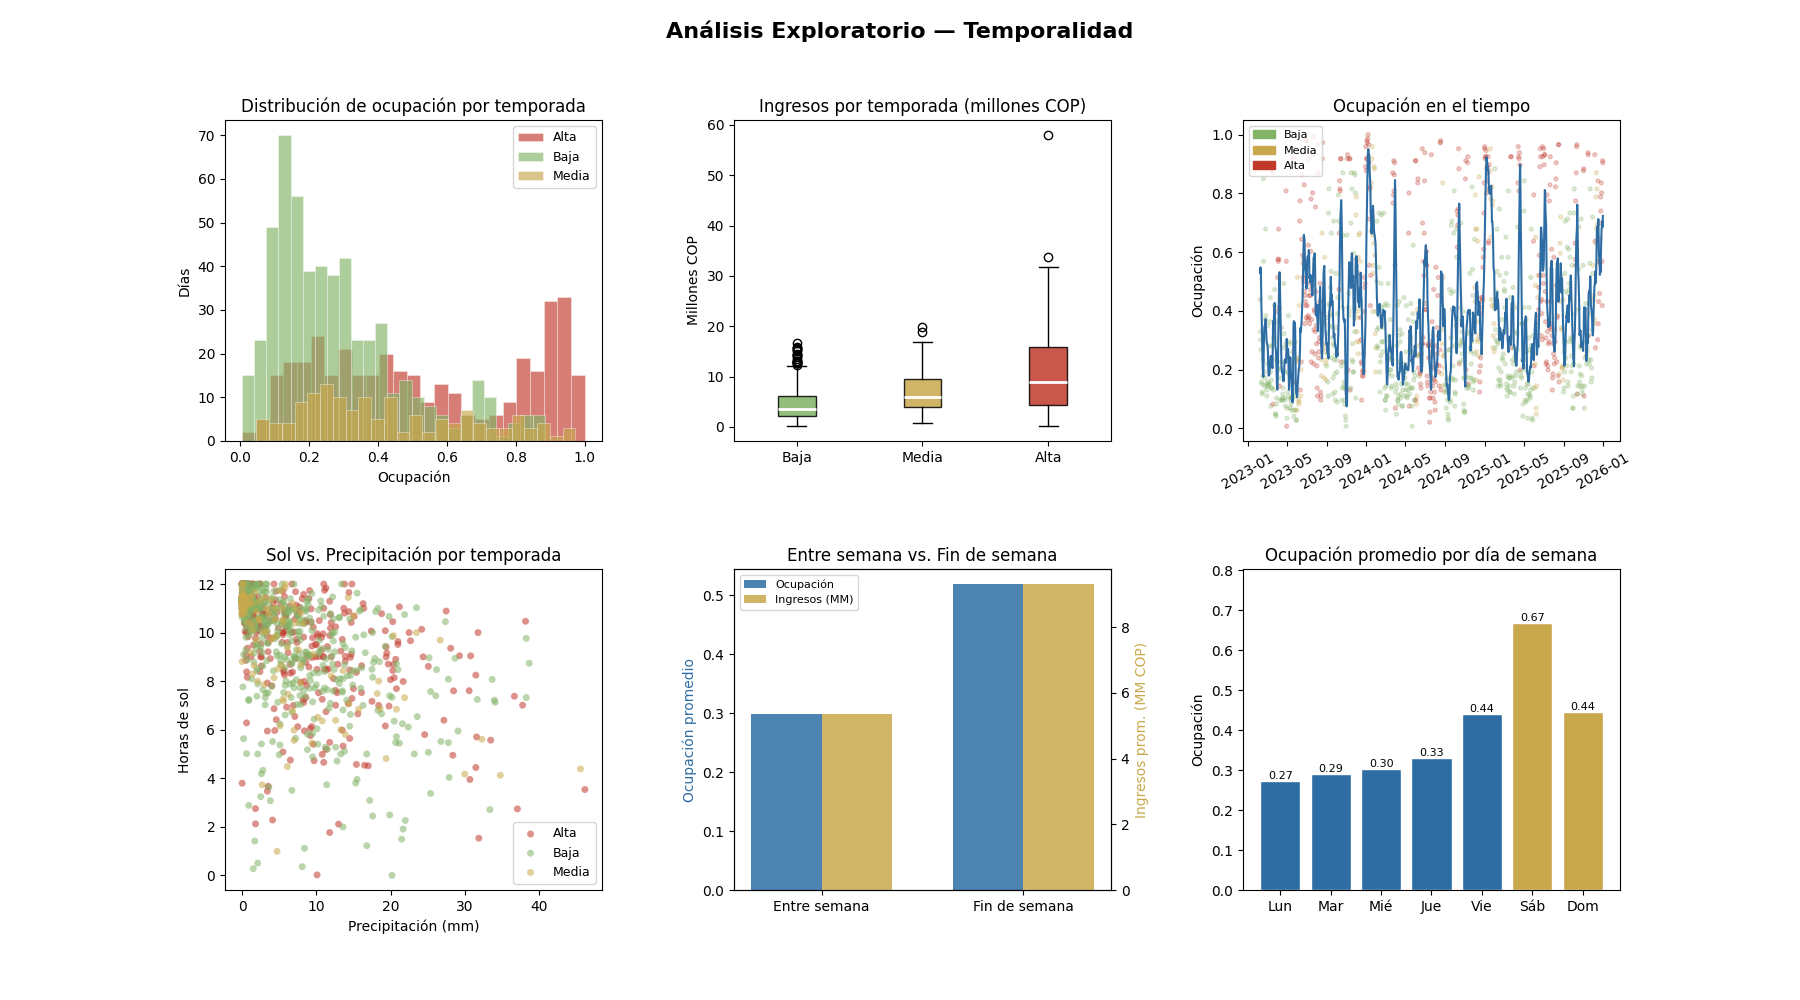

In [ ]:
from IPython.display import Image
Image('02_eda_temporalidad.png')

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 4. PREPARACIÓN DE DATOS
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("  4. PREPARACIÓN DE DATOS")
print("═"*60)

# Adding the missing import for seaborn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

# ── Agregar a nivel reserva ───────────────────────────────────────
def clasif_motivo(row):
    if pd.notna(row["id_grupo"]) and row["id_grupo"] > 0: return "Grupo"
    if row["numero_personas"] >= 4:                        return "Familia"
    if row["nombre_categoria"] in ["Junior Suite","Vista al mar","Apartamento"]:
        return "Vacacional premium"
    if row["dias_estadia"] <= 1:                           return "Negocios/transito"
    return "Vacacional"

res = df_res.groupby("id_reserva").agg(
    fecha_ingreso      =("fecha_ingreso","first"),
    dias_estadia       =("dias_estadia","first"),
    numero_personas    =("numero_personas","first"),
    nombre_categoria   =("nombre_categoria","first"),
    agencia            =("agencia","first"),
    Identificacion     =("Identificacion","first"),
    email              =("email","first"),
    nombre             =("nombre","first"),
    primer_apellido    =("primer_apellido","first"),
    Nacionalidad       =("Nacionalidad","first"),
    Año                =("Año","first"),
    ingreso_total      =("ingreso_distribuido","sum"),
    consumos_extras    =("consumos_y_extras_distribuido","sum"),
    id_grupo           =("id_grupo","first"),
).reset_index()

res["canal"]  = res["agencia"].apply(clasif_canal)
res["motivo"] = res.apply(clasif_motivo, axis=1)

# ── Unir temporalidad ─────────────────────────────────────────────
res["fecha_date"] = pd.to_datetime(res["fecha_ingreso"]).dt.normalize()
df_temp["fecha_date"] = pd.to_datetime(df_temp["fecha_noche"]).dt.normalize()

res_enr = res.merge(
    df_temp[["fecha_date","temporada","temporada_num","fin_semana",
             "ocupacion","precipitacion_mm","sol_horas","dow"]],
    on="fecha_date", how="left"
)

# ── Features a nivel cliente ──────────────────────────────────────
res_clean = res_enr.dropna(subset=["Identificacion"]).copy()
res_clean["Identificacion"] = res_clean["Identificacion"].astype(str).str.strip()
REF_DATE = pd.Timestamp("2025-01-01")

clientes = res_clean.groupby("Identificacion").agg(
    nombre              =("nombre","first"),
    apellido            =("primer_apellido","first"),
    email               =("email","first"),
    nacionalidad        =("Nacionalidad","first"),
    # RFM
    frecuencia          =("id_reserva","count"),
    recencia_dias       =("fecha_ingreso", lambda x: (REF_DATE - pd.to_datetime(x).max()).days),
    gasto_total         =("ingreso_total","sum"),
    gasto_prom_reserva  =("ingreso_total","mean"),
    consumo_extras_total=("consumos_extras","sum"),
    # Comportamiento
    dias_estadia_prom   =("dias_estadia","mean"),
    personas_prom       =("numero_personas","mean"),
    # Canal
    canal_principal     =("canal", lambda x: x.value_counts().index[0]),
    pct_ota             =("canal", lambda x: (x=="OTA/Online").mean()),
    pct_agencia         =("canal", lambda x: (x=="Agencia/Vendedor").mean()),
    # Motivo
    motivo_principal    =("motivo", lambda x: x.value_counts().index[0]),
    pct_vacacional      =("motivo", lambda x: x.isin(["Vacacional","Vacacional premium"]).mean()),
    pct_familia         =("motivo", lambda x: (x=="Familia").mean()),
    pct_negocios        =("motivo", lambda x: (x=="Negocios/transito").mean()),
    pct_premium         =("nombre_categoria", lambda x: x.isin(["Junior Suite","Vista al mar","Apartamento"]).mean()),
    # Temporalidad
    temporada_principal =("temporada", lambda x: x.value_counts().index[0] if x.notna().any() else "Baja"),
    pct_temp_alta       =("temporada", lambda x: (x=="Alta").mean()),
    pct_temp_media      =("temporada", lambda x: (x=="Media").mean()),
    pct_temp_baja       =("temporada", lambda x: (x=="Baja").mean()),
    pct_fin_semana      =("fin_semana", "mean"),
    ocupacion_contexto  =("ocupacion","mean"),
    precipitacion_prom  =("precipitacion_mm","mean"),
    sol_horas_prom      =("sol_horas","mean"),
    # Meta
    primera_visita      =("fecha_ingreso","min"),
    ultima_visita       =("fecha_ingreso","max"),
).reset_index()

clientes["recompra"] = (clientes["frecuencia"] > 1).astype(int)

print(f"  Clientes:          {len(clientes):,}")
print(f"  Tasa recompra:     {clientes['recompra'].mean():.1%}")
print(f"  Features creadas:  RFM(5) + Comportamiento(2) + Canal(2) + Motivo(4) + Temporalidad(8) = 21")

# ── Figura preparación de datos ───────────────────────────────────
FEATURES = [
    "frecuencia","recencia_dias","gasto_total","gasto_prom_reserva","consumo_extras_total",
    "dias_estadia_prom","personas_prom",
    "pct_ota","pct_agencia",
    "pct_vacacional","pct_familia","pct_negocios","pct_premium",
    "pct_temp_alta","pct_temp_media","pct_temp_baja",
    "pct_fin_semana","ocupacion_contexto","precipitacion_prom","sol_horas_prom",
]

X_raw = clientes[FEATURES].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Preparación de datos", fontsize=16, fontweight="bold")
plt.subplots_adjust(wspace=0.35)

# ── 4a. Correlación de features ───────────────────────────────────
ax = axes[0]
corr = X_raw.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.3, linecolor="white",
            cbar_kws={"shrink":0.6}, annot=False,
            xticklabels=FEATURES, yticklabels=FEATURES)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
ax.set_title("Correlación entre features")

# ── 4b. Distribución RFM antes/después de escalar ─────────────────
ax = axes[1]
rfm_cols = ["frecuencia","gasto_total","recencia_dias"]
rfm_df = pd.DataFrame(X_scaled, columns=FEATURES)[rfm_cols]
bp = ax.boxplot([rfm_df[c] for c in rfm_cols], patch_artist=True,
                labels=["Frecuencia\n(escal.)","Gasto total\n(escal.)","Recencia\n(escal.)"],
                medianprops={"color":"white","linewidth":2})
colors_bp = ["#2E6DA4","#C9A84C","#5A4E9E"]
for patch, col in zip(bp["boxes"], colors_bp):
    patch.set_facecolor(col); patch.set_alpha(0.85)
ax.set_title("Features RFM tras normalización")
ax.set_ylabel("Valor normalizado (z-score)")
ax.axhline(0, color="#C0392B", linestyle="--", linewidth=0.8, alpha=0.6)

# ── 4c. PCA — varianza explicada ─────────────────────────────────
ax = axes[2]
pca_full = PCA().fit(X_scaled)
var_exp = np.cumsum(pca_full.explained_variance_ratio_) * 100
ax.bar(range(1, len(var_exp)+1), pca_full.explained_variance_ratio_*100,
       color="#2E6DA4", alpha=0.7, edgecolor="white", label="Varianza comp.")
ax.plot(range(1, len(var_exp)+1), var_exp, color="#C0392B",
        marker="o", markersize=4, linewidth=1.5, label="Varianza acum.")
ax.axhline(80, color="#C9A84C", linestyle="--", linewidth=1, alpha=0.8, label="80% umbral")
ax.set_title("PCA — varianza explicada acumulada")
ax.set_xlabel("Componentes principales")
ax.set_ylabel("Varianza explicada (%)")
ax.legend(fontsize=8)
n80 = int(np.searchsorted(var_exp, 80)) + 1
ax.axvline(n80, color="#C9A84C", linestyle=":", linewidth=1)
ax.text(n80 + 0.2, 15, f"{n80} comp.\n≥ 80% var.", fontsize=8, color="#C9A84C")

plt.savefig("03_preparacion_datos.png")
plt.close()
print("  ✓ 03_preparacion_datos.png")


════════════════════════════════════════════════════════════
  4. PREPARACIÓN DE DATOS
════════════════════════════════════════════════════════════
  Clientes:          6,958
  Tasa recompra:     27.1%
  Features creadas:  RFM(5) + Comportamiento(2) + Canal(2) + Motivo(4) + Temporalidad(8) = 21


/tmp/ipykernel_1319/4032216370.py:142: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([rfm_df[c] for c in rfm_cols], patch_artist=True,


  ✓ 03_preparacion_datos.png


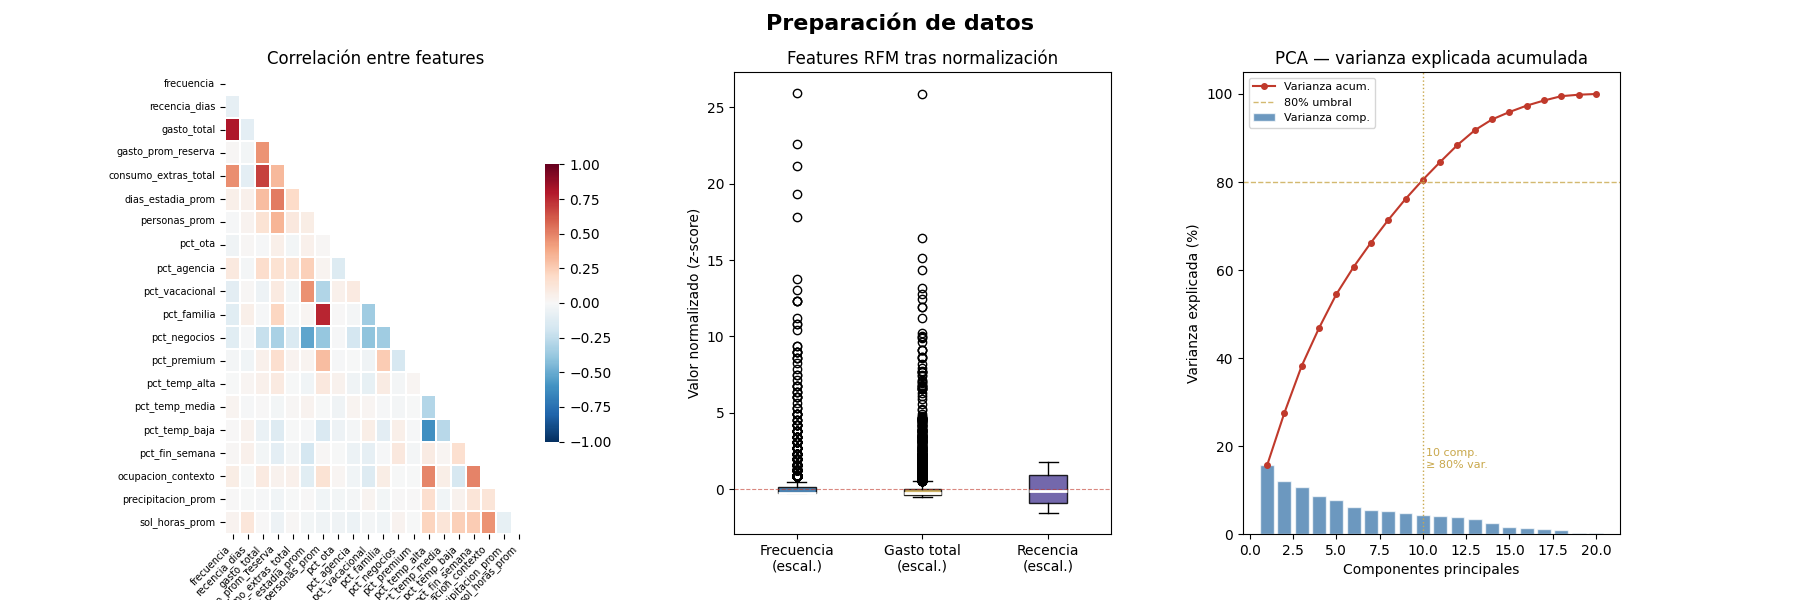

In [ ]:
from IPython.display import Image
Image('03_preparacion_datos.png')

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 5. SELECCIÓN DEL NÚMERO DE CLUSTERS
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("  5. SELECCIÓN DE K")
print("═"*60)

inercias, silhouettes_k = [], {}
K_RANGE = range(2, 11)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes_k[k] = silhouette_score(X_scaled, labels)
    print(f"  k={k:2d}  inercia={km.inertia_:,.0f}  silhouette={silhouettes_k[k]:.4f}")

K_FINAL = 7  # ≥ 5 segmentos requeridos por objetivo de negocio

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Selección del número de clusters (k)", fontsize=14, fontweight="bold")

# ── Codo ──────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(list(K_RANGE), inercias, "o-", color="#2E6DA4", linewidth=2, markersize=7)
ax.axvline(K_FINAL, color="#C0392B", linestyle="--", linewidth=1.5,
           label=f"k={K_FINAL} seleccionado")
ax.set_title("Método del codo (inercia)")
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Inercia")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# ── Silhouette ────────────────────────────────────────────────────
ax = axes[1]
ks = list(silhouettes_k.keys())
sils = list(silhouettes_k.values())
colors_sil = ["#C0392B" if k == K_FINAL else "#2E6DA4" for k in ks]
ax.bar(ks, sils, color=colors_sil, edgecolor="white", linewidth=0.6)
ax.set_title("Silhouette Score por k")
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.axhline(0.25, color="#C9A84C", linestyle="--", linewidth=1.2, label="Umbral mínimo 0.25")
ax.legend(fontsize=9)
for i, (k, s) in enumerate(zip(ks, sils)):
    ax.text(k, s + 0.003, f"{s:.3f}", ha="center", fontsize=8,
            fontweight="bold" if k == K_FINAL else "normal")

plt.savefig("04_seleccion_k.png")
plt.close()
print(f"\n  k={K_FINAL} seleccionado  |  silhouette={silhouettes_k[K_FINAL]:.4f}")
print("  ✓ 04_seleccion_k.png")


════════════════════════════════════════════════════════════
  5. SELECCIÓN DE K
════════════════════════════════════════════════════════════
  k= 2  inercia=124,811  silhouette=0.1676
  k= 3  inercia=112,793  silhouette=0.1396
  k= 4  inercia=106,013  silhouette=0.1503
  k= 5  inercia=96,533  silhouette=0.1569
  k= 6  inercia=91,514  silhouette=0.1470
  k= 7  inercia=86,209  silhouette=0.1461
  k= 8  inercia=81,416  silhouette=0.1704
  k= 9  inercia=77,642  silhouette=0.1651
  k=10  inercia=74,522  silhouette=0.1696

  k=7 seleccionado  |  silhouette=0.1461
  ✓ 04_seleccion_k.png


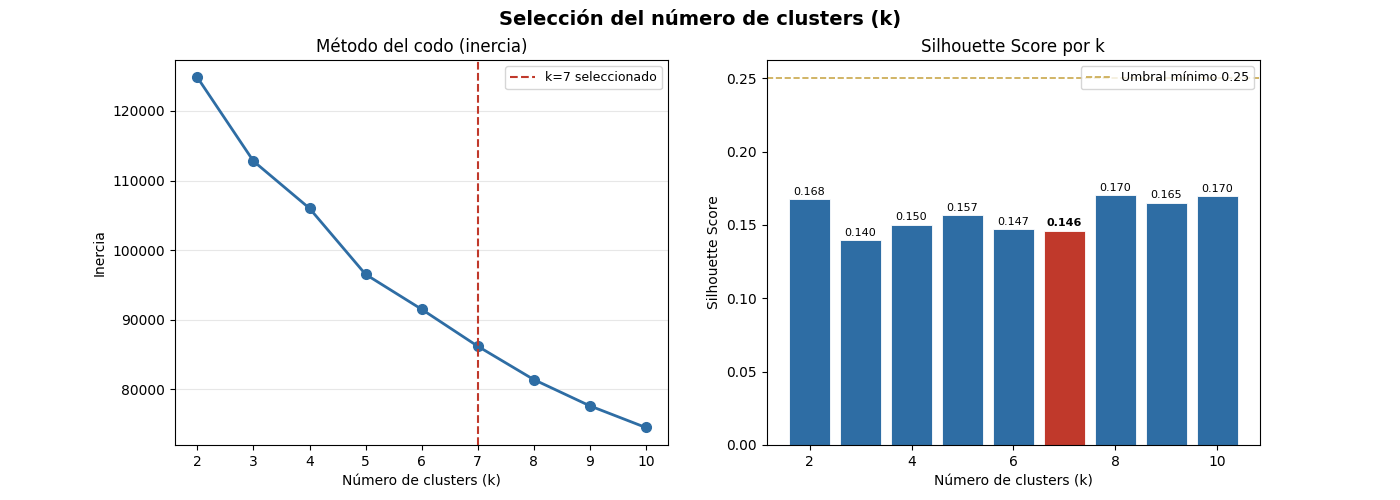

In [ ]:
from IPython.display import Image
Image('04_seleccion_k.png')

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 6. MODELO FINAL — KMEANS + VALIDACIÓN RF
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("  6. MODELO FINAL")
print("═"*60)

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
clientes["cluster_id"] = km_final.fit_predict(X_scaled)

# Nombrar segmentos (basado en perfil: mayor a menor gasto)
perfil_raw = clientes.groupby("cluster_id").agg(
    gasto=("gasto_total","mean"),
    frec =("frecuencia","mean"),
    fam  =("pct_familia","mean"),
    ota  =("pct_ota","mean"),
    neg  =("pct_negocios","mean"),
    n    =("Identificacion","count"),
).sort_values("gasto", ascending=False)

NOMBRES = {
    4: "VIP corporativos",
    0: "Leales frecuentes",
    1: "Familias premium",
    5: "Digitales OTA",
    3: "Grupos familiares",
    2: "Ocasionales estándar",
    6: "Visitantes de paso",
}
clientes["segmento"] = clientes["cluster_id"].map(NOMBRES)

# ── Random Forest — validación ────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
cv_scores = cross_val_score(rf, X_raw, clientes["cluster_id"], cv=5, scoring="accuracy")
precision = cv_scores.mean()

rf.fit(X_raw, clientes["cluster_id"])
importancias = pd.DataFrame({
    "feature":    FEATURES,
    "importancia":rf.feature_importances_
}).sort_values("importancia", ascending=False).reset_index(drop=True)

print(f"  Precisión RF (CV5): {precision:.4f}  ±{cv_scores.std():.4f}")
print(f"  {'CUMPLE ✓' if precision >= 0.85 else 'REVISAR ✗'} umbral ≥ 85%")

# ── Perfil final ──────────────────────────────────────────────────
perfil = clientes.groupby(["cluster_id","segmento"]).agg(
    clientes_n          =("Identificacion","count"),
    frecuencia_prom     =("frecuencia","mean"),
    recencia_prom       =("recencia_dias","mean"),
    gasto_total_prom    =("gasto_total","mean"),
    gasto_prom_reserva  =("gasto_prom_reserva","mean"),
    consumo_extras_prom =("consumo_extras_total","mean"),
    dias_estadia_prom   =("dias_estadia_prom","mean"),
    personas_prom       =("personas_prom","mean"),
    tasa_recompra       =("recompra","mean"),
    pct_ota             =("pct_ota","mean"),
    pct_agencia         =("pct_agencia","mean"),
    pct_familia         =("pct_familia","mean"),
    pct_negocios        =("pct_negocios","mean"),
    pct_premium         =("pct_premium","mean"),
    pct_temp_alta       =("pct_temp_alta","mean"),
    pct_temp_media      =("pct_temp_media","mean"),
    pct_temp_baja       =("pct_temp_baja","mean"),
    pct_vacacional      =("pct_vacacional","mean"),
    pct_fin_semana      =("pct_fin_semana","mean"),
    precipitacion_prom  =("precipitacion_prom","mean"),
    ocupacion_contexto  =("ocupacion_contexto","mean"),
    sol_horas_prom      =("sol_horas_prom","mean"),
    temporada_principal =("temporada_principal", lambda x: x.value_counts().index[0]),
).reset_index().sort_values("gasto_total_prom", ascending=False).reset_index(drop=True)


════════════════════════════════════════════════════════════
  6. MODELO FINAL
════════════════════════════════════════════════════════════
  Precisión RF (CV5): 0.9747  ±0.0015
  CUMPLE ✓ umbral ≥ 85%


In [ ]:
# ══════════════════════════════════════════════════════════════════
# 7. GRÁFICA — PERFIL DE SEGMENTOS
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("  7. GRÁFICA — PERFIL DE SEGMENTOS")
print("═"*60)

# Define the color palette for segments
PALETTE = {
    "VIP corporativos": "#1B3A5C",
    "Leales frecuentes": "#2E6DA4",
    "Familias premium": "#5A4E9E",
    "Digitales OTA": "#C9A84C",
    "Grupos familiares": "#82B366",
    "Ocasionales estándar": "#C0392B",
    "Visitantes de paso": "#8A8A8A",
}

seg_order = perfil["segmento"].tolist()
seg_colors = [PALETTE[s] for s in seg_order]

fig = plt.figure(figsize=(18, 13))
fig.suptitle("Perfil de segmentos de clientes", fontsize=16, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

# ── 7a. Tamaño de segmentos ───────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
wedges, texts, autotexts = ax.pie(
    perfil["clientes_n"],
    labels=None,
    colors=seg_colors,
    autopct=lambda p: f"{p:.1f}%",
    startangle=140,
    wedgeprops={"linewidth":0.8,"edgecolor":"white"})
for at in autotexts: at.set_fontsize(8)
ax.set_title("Distribución de clientes")
ax.legend(seg_order, loc="lower center", bbox_to_anchor=(0.5, -0.35),
          fontsize=7, frameon=False, ncol=2)

# ── 7b. Gasto total promedio ──────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
bars = ax.barh(perfil["segmento"], perfil["gasto_total_prom"] / 1e6,
               color=seg_colors, edgecolor="white")
ax.set_title("Gasto total promedio (MM COP)")
ax.set_xlabel("Millones COP")
for b in bars:
    ax.text(b.get_width() + 0.1, b.get_y() + b.get_height()/2,
            f"${b.get_width():.1f}M", va="center", fontsize=8)

# ── 7c. Tasa de recompra ─────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
bars = ax.barh(perfil["segmento"], perfil["tasa_recompra"] * 100,
               color=seg_colors, edgecolor="white")
ax.set_title("Tasa de recompra (%)")
ax.set_xlabel("%")
ax.axvline(clientes["recompra"].mean() * 100, color="#C0392B",
           linestyle="--", linewidth=1.5, label=f"Global: {clientes['recompra'].mean():.1%}")
ax.legend(fontsize=8)
for b in bars:
    ax.text(b.get_width() + 0.5, b.get_y() + b.get_height()/2,
            f"{b.get_width():.1f}%", va="center", fontsize=8)

# ── 7d. Frecuencia vs Recencia ────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
for _, row in perfil.iterrows():
    ax.scatter(row["recencia_prom"], row["frecuencia_prom"],
               s=row["clientes_n"] / 6,
               color=PALETTE[row["segmento"]], alpha=0.85, edgecolors="white",
               linewidths=0.5, zorder=3)
    ax.annotate(row["segmento"].split()[0],
                (row["recencia_prom"], row["frecuencia_prom"]),
                textcoords="offset points", xytext=(5, 3), fontsize=7)
ax.set_title("Frecuencia vs. Recencia\n(tamaño = N° clientes)")
ax.set_xlabel("Recencia promedio (días)")
ax.set_ylabel("Frecuencia promedio")
ax.axvline(0, color="gray", linestyle=":", linewidth=0.8, alpha=0.5)

# ── 7e. Canal de reserva por segmento ────────────────────────────
ax = fig.add_subplot(gs[1, 1])
canal_df = perfil[["segmento","pct_ota","pct_agencia"]].copy()
canal_df["pct_directo"] = 1 - canal_df["pct_ota"] - canal_df["pct_agencia"]
y = np.arange(len(canal_df))
w = 0.25
ax.barh(y - w, canal_df["pct_ota"]*100,     w, label="OTA/Online",       color="#2E8B7A", edgecolor="white")
ax.barh(y,     canal_df["pct_agencia"]*100, w, label="Agencia/Vendedor",  color="#5A4E9E", edgecolor="white")
ax.barh(y + w, canal_df["pct_directo"]*100, w, label="Directo",           color="#2E6DA4", edgecolor="white")
ax.set_yticks(y)
ax.set_yticklabels(canal_df["segmento"], fontsize=8)
ax.set_title("Canal de reserva por segmento (%)")
ax.set_xlabel("%")
ax.legend(fontsize=7, loc="lower right")

# ── 7f. Motivo de viaje por segmento ─────────────────────────────
ax = fig.add_subplot(gs[1, 2])
mot_df = perfil[["segmento","pct_familia","pct_negocios","pct_vacacional"]].copy()
y = np.arange(len(mot_df))
w = 0.25
ax.barh(y - w, mot_df["pct_vacacional"]*100, w, label="Vacacional", color="#C9A84C", edgecolor="white")
ax.barh(y,     mot_df["pct_familia"]*100,    w, label="Familia",    color="#2E6DA4", edgecolor="white")
ax.barh(y + w, mot_df["pct_negocios"]*100,   w, label="Negocios",   color="#8A8A8A", edgecolor="white")
ax.set_yticks(y)
ax.set_yticklabels(mot_df["segmento"], fontsize=8)
ax.set_title("Motivo de viaje por segmento (%)")
ax.set_xlabel("%")
ax.legend(fontsize=7)

# ── 7g. PCA 2D con clusters ───────────────────────────────────────
ax = fig.add_subplot(gs[2, :2])
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_scaled)
var1, var2 = pca2.explained_variance_ratio_ * 100

for seg in clientes["segmento"].unique():
    mask = clientes["segmento"] == seg
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=PALETTE.get(seg, "#888"), alpha=0.35, s=12,
               edgecolors="none", label=seg)
ax.set_title(f"Clusters en espacio PCA  (PC1 {var1:.1f}% · PC2 {var2:.1f}% varianza)")
ax.set_xlabel(f"PC1 ({var1:.1f}%)")
ax.set_ylabel(f"PC2 ({var2:.1f}%)")
ax.legend(fontsize=7, markerscale=2, loc="upper right")

# ── 7h. Gasto promedio por reserva ───────────────────────────────
ax = fig.add_subplot(gs[2, 2])
ax.bar(range(len(perfil)), perfil["gasto_prom_reserva"] / 1e3,
       color=seg_colors, edgecolor="white")
ax.set_xticks(range(len(perfil)))
ax.set_xticklabels([s.split()[0] for s in perfil["segmento"]],
                   rotation=30, ha="right", fontsize=8)
ax.set_title("Gasto promedio por reserva (miles COP)")
ax.set_ylabel("Miles COP")

plt.savefig("05_segmentos_perfil.png")
plt.close()
print("  ✓ 05_segmentos_perfil.png")


════════════════════════════════════════════════════════════
  7. GRÁFICA — PERFIL DE SEGMENTOS
════════════════════════════════════════════════════════════
  ✓ 05_segmentos_perfil.png


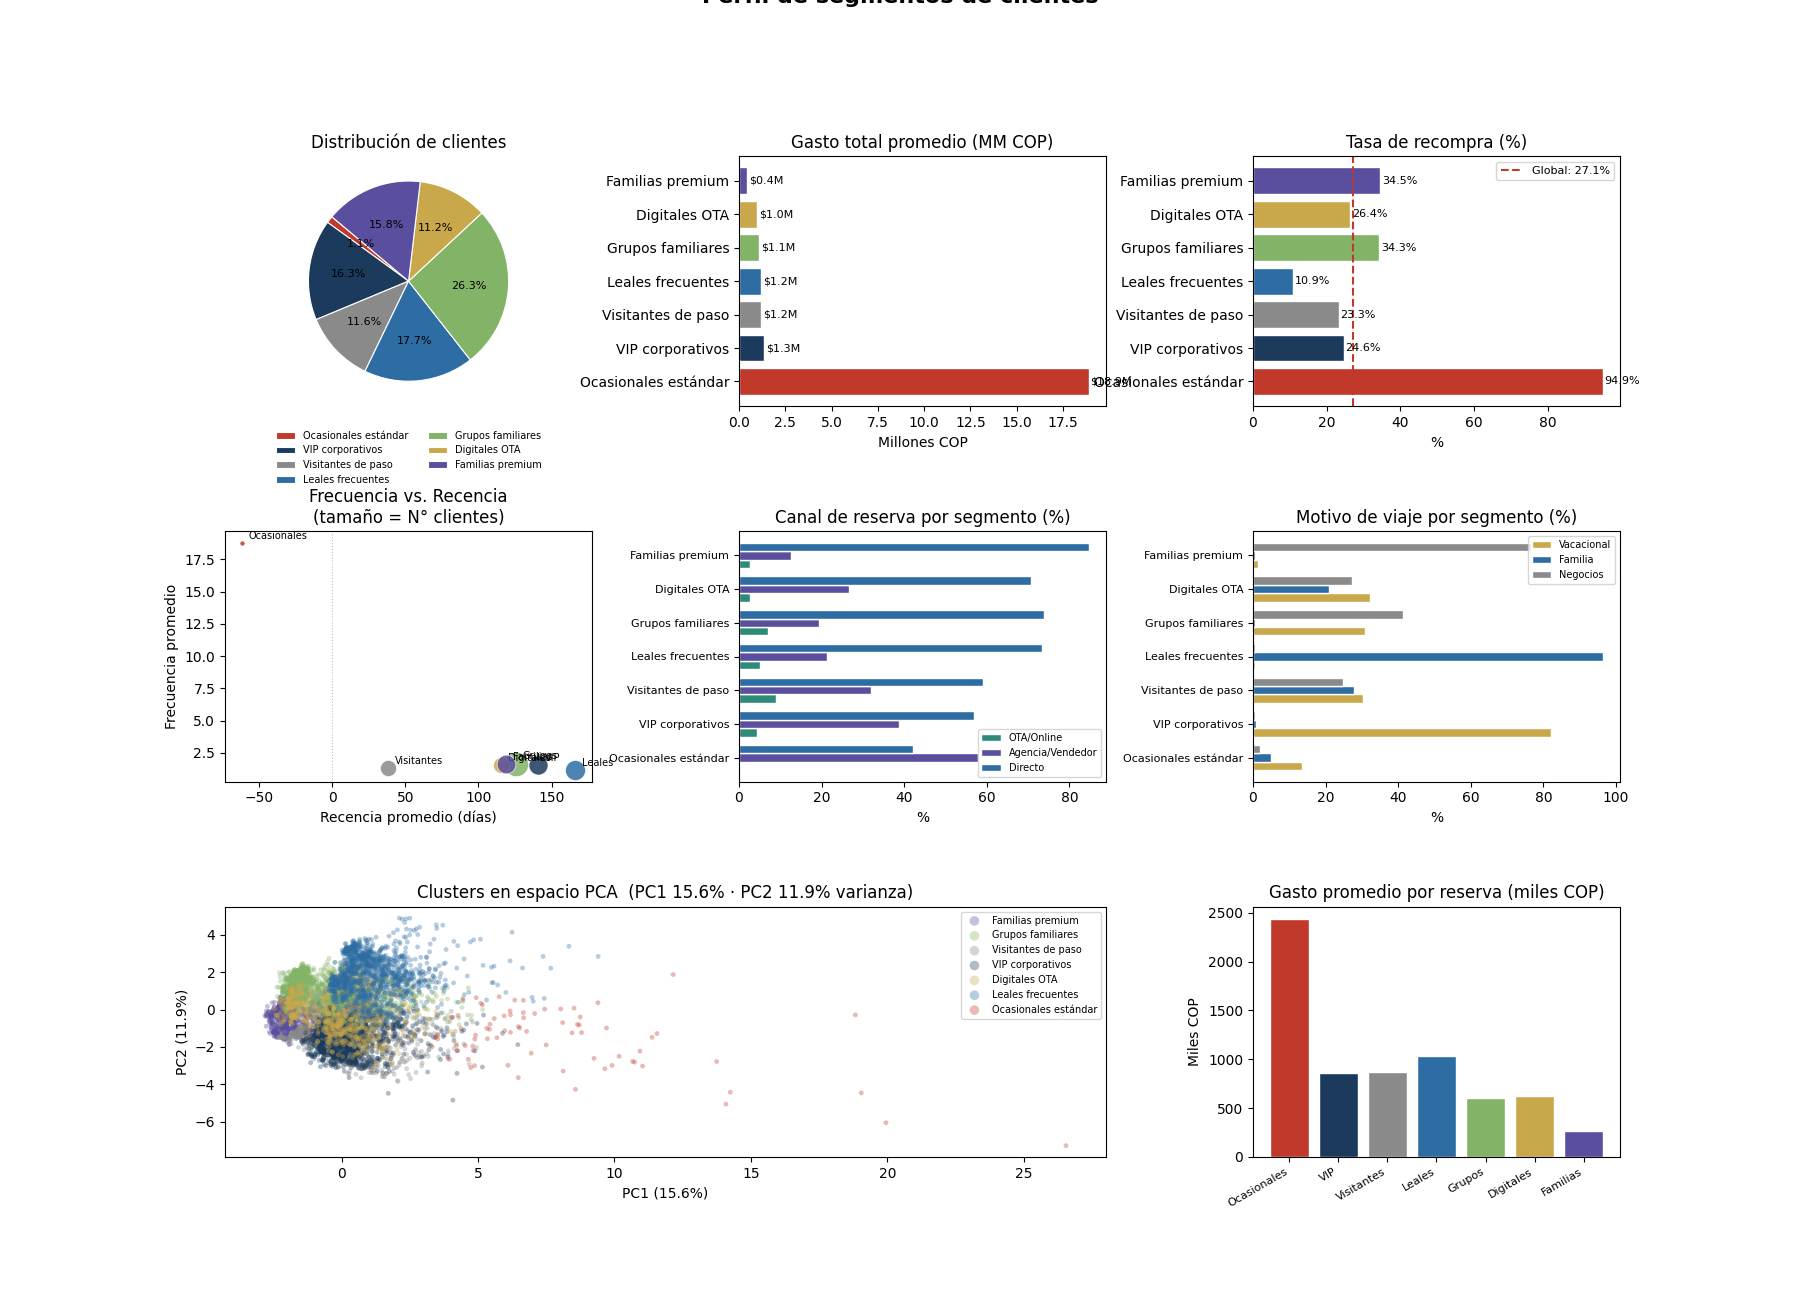

In [ ]:
from IPython.display import Image
Image('05_segmentos_perfil.png')

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 8. GRÁFICA — TEMPORALIDAD POR SEGMENTO
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("  8. GRÁFICA — TEMPORALIDAD POR SEGMENTO")
print("═"*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Temporalidad por segmento de clientes", fontsize=16, fontweight="bold")
plt.subplots_adjust(hspace=0.45, wspace=0.38)

# ── 8a. Distribución de temporadas por segmento (stacked) ────────
ax = axes[0, 0]
temp_stack = perfil[["segmento","pct_temp_alta","pct_temp_media","pct_temp_baja"]].set_index("segmento")
temp_stack.columns = ["Alta","Media","Baja"]
temp_stack_pct = temp_stack.mul(100)
bottom = np.zeros(len(temp_stack_pct))
for temp_col, col_color in zip(["Alta","Media","Baja"],
                                [TEMPORADA_PAL["Alta"],TEMPORADA_PAL["Media"],TEMPORADA_PAL["Baja"]]):
    vals = temp_stack_pct[temp_col].values
    bars = ax.barh(temp_stack_pct.index, vals, left=bottom,
                   color=col_color, edgecolor="white", label=temp_col)
    bottom += vals
ax.set_title("Distribución de temporadas por segmento")
ax.set_xlabel("%")
ax.legend(fontsize=8, loc="lower right")
ax.set_xlim(0, 115)

# ── 8b. % Fin de semana por segmento ─────────────────────────────
ax = axes[0, 1]
bars = ax.bar(range(len(perfil)), perfil["pct_fin_semana"] * 100,
              color=seg_colors, edgecolor="white")
ax.set_xticks(range(len(perfil)))
ax.set_xticklabels([s.split()[0] for s in perfil["segmento"]],
                   rotation=30, ha="right", fontsize=8)
ax.axhline(df_temp["fin_semana"].mean()*100, color="#C0392B", linestyle="--",
           linewidth=1.5, label=f"Global: {df_temp['fin_semana'].mean():.0%}")
ax.set_title("% llegadas en fin de semana")
ax.set_ylabel("%")
ax.legend(fontsize=8)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
            f"{b.get_height():.0f}%", ha="center", fontsize=8)

# ── 8c. Ocupación contextual promedio ────────────────────────────
ax = axes[0, 2]
bars = ax.bar(range(len(perfil)), perfil["ocupacion_contexto"] * 100,
              color=seg_colors, edgecolor="white")
ax.set_xticks(range(len(perfil)))
ax.set_xticklabels([s.split()[0] for s in perfil["segmento"]],
                   rotation=30, ha="right", fontsize=8)
ax.axhline(df_temp["ocupacion"].mean()*100, color="#C0392B", linestyle="--",
           linewidth=1.5, label=f"Ocup. global: {df_temp['ocupacion'].mean():.0%}")
ax.set_title("Ocupación contextual promedio (%)")
ax.set_ylabel("Ocupación promedio del hotel")
ax.legend(fontsize=8)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
            f"{b.get_height():.0f}%", ha="center", fontsize=8)

# ── 8d. Heatmap temporada × segmento (recompra) ──────────────────
ax = axes[1, 0]
heat_data = clientes.groupby(["segmento","temporada_principal"])["recompra"].mean().unstack(fill_value=0)
sns.heatmap(heat_data * 100, ax=ax, cmap="YlOrRd", annot=True, fmt=".0f",
            linewidths=0.5, linecolor="white", cbar_kws={"label":"Tasa recompra (%)"})
ax.set_title("Tasa recompra por segmento × temporada (%)")
ax.set_xlabel("Temporada principal")
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=8)

# ── 8e. Sol y Precipitación por segmento ─────────────────────────
ax = axes[1, 1]
x_pos = np.arange(len(perfil))
w = 0.35
ax.bar(x_pos - w/2, perfil["sol_horas_prom"], w,
       color="#C9A84C", edgecolor="white", label="Horas de sol")
ax2e = ax.twinx()
ax2e.bar(x_pos + w/2, perfil["sol_horas_prom"] * 0,   # placeholder
         w, color="#2E86C1", edgecolor="white", label="Precipitación")
# Recalcular con datos reales
ax.cla()
ax.bar(x_pos - w/2, perfil["sol_horas_prom"], w,
       color="#C9A84C", edgecolor="white", label="Horas sol prom.")
ax.set_xticks(x_pos)
ax.set_xticklabels([s.split()[0] for s in perfil["segmento"]],
                   rotation=30, ha="right", fontsize=8)
ax.set_title("Sol y Precipitación en días de visita")
ax.set_ylabel("Horas de sol", color="#C9A84C")
ax.legend(loc="upper left", fontsize=8)

# Precipitación en eje secundario
ax2e.cla()
ax2e.bar(x_pos + w/2, perfil["precipitacion_prom"] if "precipitacion_prom" in perfil.columns
         else [0]*len(perfil), w, color="#2E86C1", edgecolor="white", alpha=0.8,
         label="Precipitación (mm)")
ax2e.set_ylabel("Precipitación promedio (mm)", color="#2E86C1")
ax2e.legend(loc="upper right", fontsize=8)

# ── 8f. Ingreso × temporada ──────────────────────────────────────
ax = axes[1, 2]
seg_temp_data = []
for seg in seg_order:
    sub_ids = clientes[clientes["segmento"] == seg]["Identificacion"]
    sub_enr = res_enr[res_enr["Identificacion"].isin(sub_ids)]
    for temp in ["Alta","Media","Baja"]:
        rows = sub_enr[sub_enr["temporada"] == temp]["ingreso_total"]
        if len(rows) > 0:
            seg_temp_data.append({"segmento":seg,"temporada":temp,
                                   "gasto_prom":rows.mean()})

seg_temp_df = pd.DataFrame(seg_temp_data)
if not seg_temp_df.empty:
    for temp, col in TEMPORADA_PAL.items():
        sub_t = seg_temp_df[seg_temp_df["temporada"] == temp]
        if not sub_t.empty:
            x_idx = [seg_order.index(s) for s in sub_t["segmento"]]
            ax.scatter(x_idx, sub_t["gasto_prom"] / 1e6,
                       color=col, s=80, zorder=3, label=temp,
                       edgecolors="white", linewidths=0.5)
            ax.plot(x_idx, sub_t["gasto_prom"] / 1e6,
                    color=col, alpha=0.4, linewidth=1)
ax.set_xticks(range(len(seg_order)))
ax.set_xticklabels([s.split()[0] for s in seg_order], rotation=30, ha="right", fontsize=8)
ax.set_title("Gasto promedio por temporada y segmento")
ax.set_ylabel("Millones COP")
ax.legend(fontsize=8, title="Temporada")

plt.savefig("06_segmentos_temporalidad.png")
plt.close()
print("  ✓ 06_segmentos_temporalidad.png")


════════════════════════════════════════════════════════════
  8. GRÁFICA — TEMPORALIDAD POR SEGMENTO
════════════════════════════════════════════════════════════
  ✓ 06_segmentos_temporalidad.png


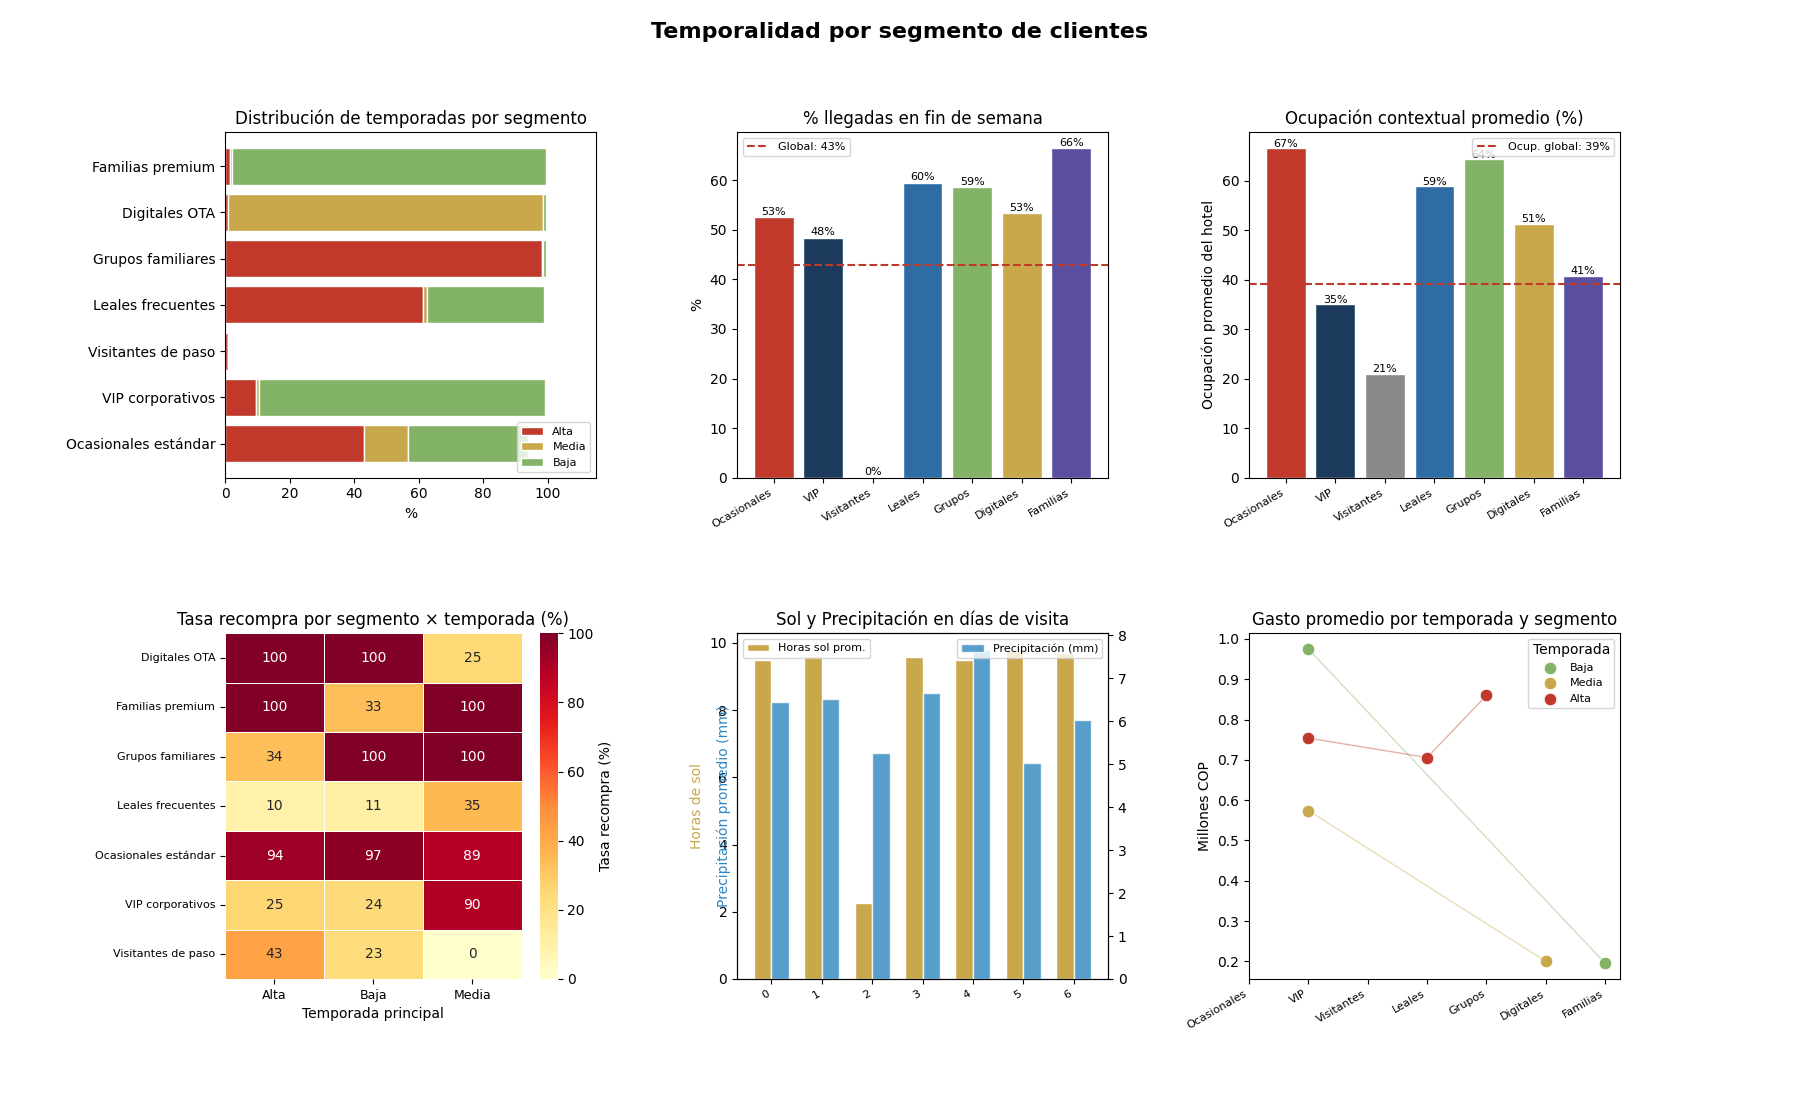

In [ ]:
from IPython.display import Image
Image('06_segmentos_temporalidad.png')

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 9. IMPORTANCIA DE VARIABLES
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("  9. IMPORTANCIA DE VARIABLES")
print("═"*60)

TIPO_MAP = {
    "frecuencia":"RFM","recencia_dias":"RFM","gasto_total":"RFM",
    "gasto_prom_reserva":"RFM","consumo_extras_total":"RFM",
    "dias_estadia_prom":"Comportamiento","personas_prom":"Comportamiento",
    "pct_ota":"Canal","pct_agencia":"Canal",
    "pct_vacacional":"Motivo","pct_familia":"Motivo",
    "pct_negocios":"Motivo","pct_premium":"Categoría",
    "pct_temp_alta":"Temporalidad","pct_temp_media":"Temporalidad",
    "pct_temp_baja":"Temporalidad","pct_fin_semana":"Temporalidad",
    "ocupacion_contexto":"Temporalidad","precipitacion_prom":"Temporalidad",
    "sol_horas_prom":"Temporalidad",
}
TIPO_PAL = {
    "RFM":"#2E6DA4","Comportamiento":"#5A4E9E","Canal":"#2E8B7A",
    "Motivo":"#C9A84C","Categoría":"#8A8A8A","Temporalidad":"#C0392B",
}

importancias["tipo"] = importancias["feature"].map(TIPO_MAP)
importancias["color"] = importancias["tipo"].map(TIPO_PAL)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Importancia de variables — Random Forest", fontsize=14, fontweight="bold")

# ── 9a. Ranking de variables ──────────────────────────────────────
ax = axes[0]
imp_sorted = importancias.sort_values("importancia")
ax.barh(imp_sorted["feature"], imp_sorted["importancia"] * 100,
        color=imp_sorted["color"], edgecolor="white", linewidth=0.5)
ax.set_title(f"Importancia por variable (Acc. CV5: {precision:.1%})")
ax.set_xlabel("Importancia (%)")
handles_legend = [mpatches.Patch(color=c, label=t) for t, c in TIPO_PAL.items()
                  if t in importancias["tipo"].values]
ax.legend(handles=handles_legend, fontsize=8, loc="lower right")

# ── 9b. Importancia agrupada por tipo ────────────────────────────
ax = axes[1]
imp_tipo = importancias.groupby("tipo")["importancia"].sum().sort_values(ascending=False)
colors_tipo = [TIPO_PAL[t] for t in imp_tipo.index]
wedges, texts, auts = ax.pie(
    imp_tipo.values,
    labels=imp_tipo.index,
    autopct=lambda p: f"{p:.1f}%",
    colors=colors_tipo,
    startangle=140,
    wedgeprops={"linewidth":0.8,"edgecolor":"white"})
for at in auts: at.set_fontsize(9)
ax.set_title("Importancia total por grupo de variables")

plt.savefig("07_importancia_variables.png")
plt.close()
print("  ✓ 07_importancia_variables.png")


════════════════════════════════════════════════════════════
  9. IMPORTANCIA DE VARIABLES
════════════════════════════════════════════════════════════
  ✓ 07_importancia_variables.png


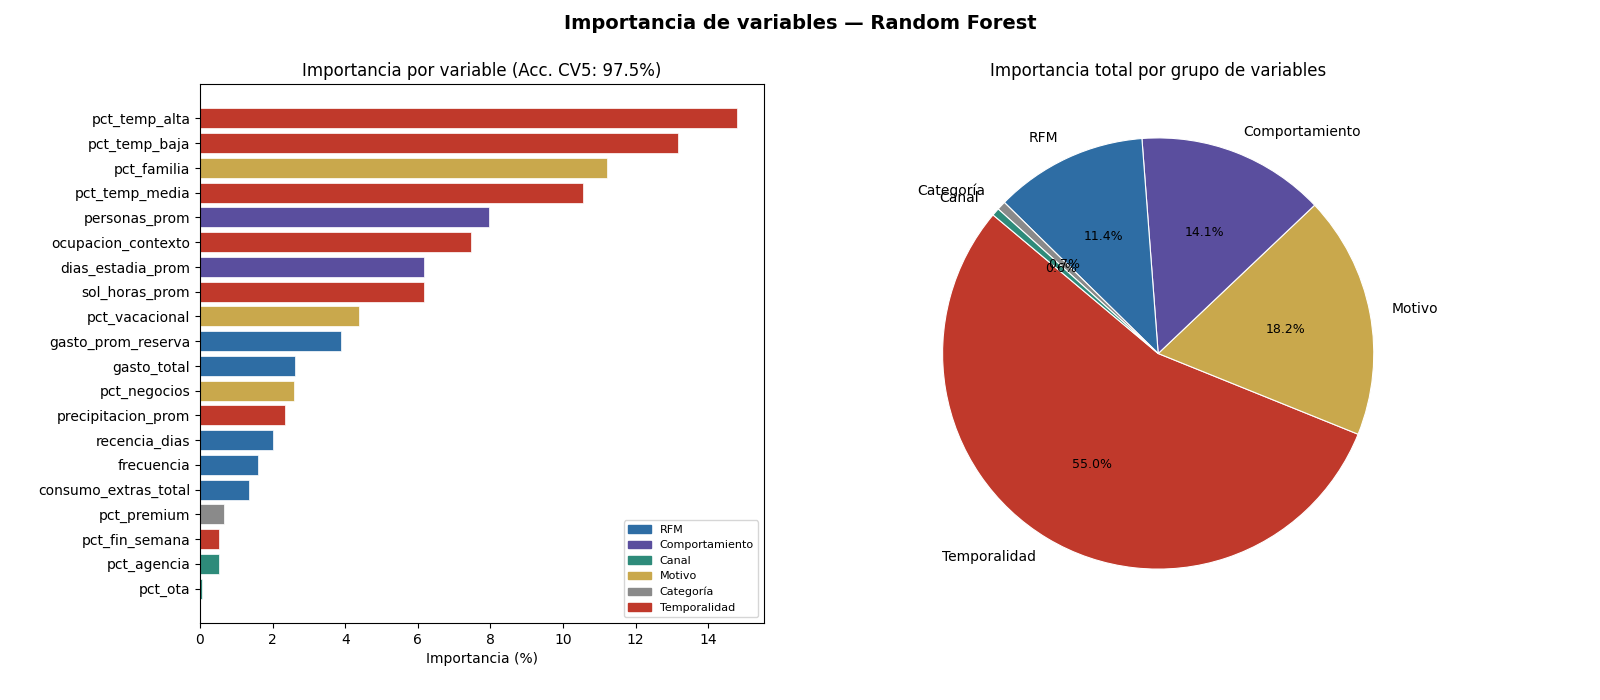

In [ ]:
from IPython.display import Image
Image('07_importancia_variables.png')

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 10. RADAR — PERFIL MULTIDIMENSIONAL
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("  10. RADAR — PERFIL MULTIDIMENSIONAL")
print("═"*60)

# Dimensiones normalizadas 0-1 para radar
radar_dims = {
    "Gasto":         "gasto_total_prom",
    "Frecuencia":    "frecuencia_prom",
    "Recompra":      "tasa_recompra",
    "Premium":       "pct_premium",
    "Familia":       "pct_familia",
    "OTA":           "pct_ota",
    "Temp. Alta":    "pct_temp_alta",
    "Fin Semana":    "pct_fin_semana",
}

labels = list(radar_dims.keys())
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 4, figsize=(20, 10),
                          subplot_kw={"projection": "polar"})
fig.suptitle("Perfil multidimensional por segmento (radar)", fontsize=15, fontweight="bold")
plt.subplots_adjust(hspace=0.5, wspace=0.4)

# Normalizar cada dimensión 0-1
radar_df = perfil[["segmento"] + list(radar_dims.values())].copy()
for col in radar_dims.values():
    mn, mx = radar_df[col].min(), radar_df[col].max()
    radar_df[col] = (radar_df[col] - mn) / (mx - mn + 1e-9)

for idx, (_, row) in enumerate(radar_df.iterrows()):
    ax = axes[idx // 4][idx % 4]
    values = [row[col] for col in radar_dims.values()]
    values += values[:1]
    seg = row["segmento"]
    color = PALETTE.get(seg, "#888")
    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, alpha=0.25, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=8)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["25","50","75","100"], size=6, color="gray")
    ax.set_title(seg, size=9, fontweight="bold", pad=12, color=color)
    ax.spines["polar"].set_visible(False)
    ax.grid(color="gray", alpha=0.3, linewidth=0.5)

# Ocultar el subplot sobrante (si hay)
if len(radar_df) < 8:
    axes[1][3].set_visible(False)

plt.savefig("08_radar_segmentos.png")
plt.close()
print("  ✓ 08_radar_segmentos.png")


════════════════════════════════════════════════════════════
  10. RADAR — PERFIL MULTIDIMENSIONAL
════════════════════════════════════════════════════════════
  ✓ 08_radar_segmentos.png


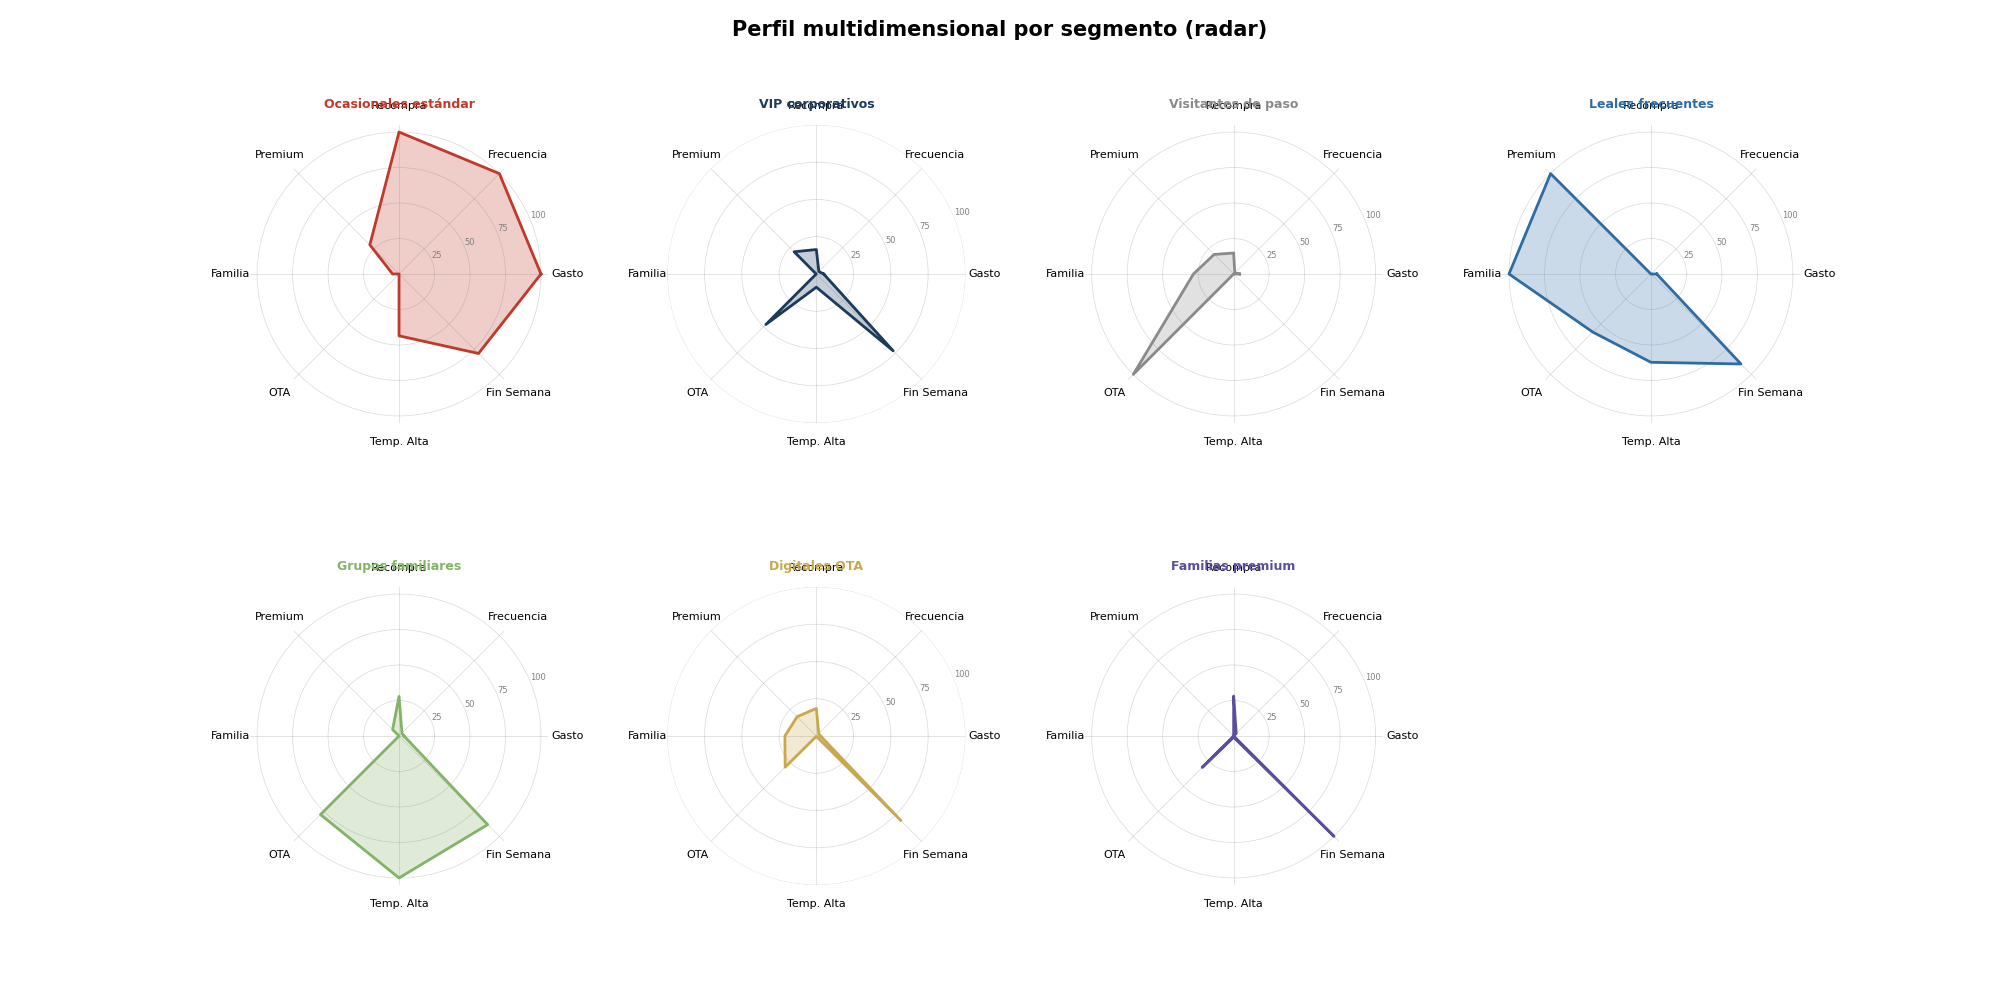

In [ ]:
from IPython.display import Image
Image('08_radar_segmentos.png')

In [ ]:
import openpyxl
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side
from openpyxl.utils import get_column_letter

# ══════════════════════════════════════════════════════════════════
# 11. EXCEL DE RESULTADOS
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("  11. GENERANDO EXCEL")
print("═"*60)

DARK_BLUE  = "1B3A5C"
MID_BLUE   = "2E6DA4"
PALE_BLUE  = "DEEAF6"
WHITE      = "FFFFFF"
GRAY_LIGHT = "F2F2F2"
TEXT_DARK  = "1A1A1A"
GREEN_BG   = "E2F4E4"
GREEN_FG   = "0B5E14"

SEG_COLORS_XL = {
    "VIP corporativos":      ("1B3A5C","FFFFFF"),
    "Leales frecuentes":     ("2E6DA4","FFFFFF"),
    "Familias premium":      ("C9A84C","FFFFFF"),
    "Digitales OTA":         ("2E8B7A","FFFFFF"),
    "Grupos familiares":     ("5A4E9E","FFFFFF"),
    "Ocasionales estándar":  ("8A8A8A","FFFFFF"),
    "Visitantes de paso":    ("82B366","FFFFFF"),
}

def thin_brd():
    s = Side(style="thin", color="CCCCCC")
    return Border(left=s, right=s, top=s, bottom=s)

def hdr(ws, row, col, text, bg=DARK_BLUE, fg=WHITE, sz=10, bold=True):
    c = ws.cell(row=row, column=col, value=text)
    c.font = Font(name="Arial", bold=bold, color=fg, size=sz)
    c.fill = PatternFill("solid", fgColor=bg)
    c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    c.border = thin_brd()
    return c

def cel(ws, row, col, value, bg=WHITE, fg=TEXT_DARK, bold=False, fmt=None, al="left"):
    c = ws.cell(row=row, column=col, value=value)
    c.font = Font(name="Arial", bold=bold, color=fg, size=9)
    c.fill = PatternFill("solid", fgColor=bg)
    c.alignment = Alignment(horizontal=al, vertical="center", wrap_text=True)
    if fmt: c.number_format = fmt
    c.border = thin_brd()
    return c

wb = openpyxl.Workbook()

# ── Hoja 1: Resumen Ejecutivo ─────────────────────────────────────
ws1 = wb.active
ws1.title = "Resumen Ejecutivo"
ws1.sheet_view.showGridLines = False
for col, w in [("A",26),("B",14),("C",14),("D",20),("E",20),("F",14),("G",18)]:
    ws1.column_dimensions[col].width = w

ws1.row_dimensions[1].height = 44
ws1.merge_cells("A1:G1")
c = ws1["A1"]
c.value = "MODELO DE SEGMENTACIÓN DE CLIENTES CON TEMPORALIDAD — HOTEL"
c.font = Font(name="Arial", bold=True, color=WHITE, size=14)
c.fill = PatternFill("solid", fgColor=DARK_BLUE)
c.alignment = Alignment(horizontal="center", vertical="center")

ws1.row_dimensions[2].height = 20
ws1.merge_cells("A2:G2")
c = ws1["A2"]
base_rcp = clientes["recompra"].mean()
c.value = (f"Precisión: {precision:.1%} | Silhouette: {silhouettes_k[K_FINAL]:.3f} | "
           f"Recompra base: {base_rcp:.1%} | Meta: {base_rcp+0.07:.1%}")
c.font = Font(name="Arial", color=DARK_BLUE, size=9, italic=True)
c.fill = PatternFill("solid", fgColor=PALE_BLUE)
c.alignment = Alignment(horizontal="center", vertical="center")

ws1.row_dimensions[3].height = 8
kpi_data = [
    ("A","Clientes", f"{len(clientes):,}"),
    ("B","Segmentos", str(K_FINAL)),
    ("C","Precisión RF", f"{precision:.1%}"),
    ("D","Recompra base", f"{base_rcp:.1%}"),
    ("E","Meta recompra", f"{base_rcp+0.07:.1%}"),
    ("F","Silhouette", f"{silhouettes_k[K_FINAL]:.3f}"),
    ("G","Período", "2023–2026"),
]
for col_l, lbl, val in kpi_data:
    c1 = ws1[f"{col_l}4"]
    c1.value = lbl
    c1.font = Font(name="Arial", bold=True, color=WHITE, size=9)
    c1.fill = PatternFill("solid", fgColor=MID_BLUE)
    c1.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    c1.border = thin_brd()
    ws1.row_dimensions[4].height = 28
    c2 = ws1[f"{col_l}5"]
    c2.value = val
    c2.font = Font(name="Arial", bold=True, color=DARK_BLUE, size=16)
    c2.fill = PatternFill("solid", fgColor=PALE_BLUE)
    c2.alignment = Alignment(horizontal="center", vertical="center") # Corrected line
    c2.border = thin_brd()
    ws1.row_dimensions[5].height = 34

ws1.row_dimensions[6].height = 8
ws1.merge_cells("A7:G7")
c = ws1["A7"]
c.value = "PERFIL CONSOLIDADO DE SEGMENTOS"
c.font = Font(name="Arial", bold=True, color=WHITE, size=11)
c.fill = PatternFill("solid", fgColor=DARK_BLUE)
c.alignment = Alignment(horizontal="center", vertical="center")
ws1.row_dimensions[7].height = 26

hdrs1 = ["Segmento","Clientes","Frecuencia","Gasto Total Prom. (COP)",
         "Tasa Recompra","Temporada Ppal.","% Fin Semana"]
ws1.row_dimensions[8].height = 26
for j, h in enumerate(hdrs1, 1):
    hdr(ws1, 8, j, h)

for i, row in perfil.iterrows():
    r = 9 + i
    ws1.row_dimensions[r].height = 22
    seg = row["segmento"]
    bg_s, fg_s = SEG_COLORS_XL.get(seg, (GRAY_LIGHT, TEXT_DARK))
    alt = GRAY_LIGHT if i % 2 else WHITE
    row_data = [
        (seg,                           bg_s, fg_s, True,  None,    "left"),
        (int(row["clientes_n"]),        alt, TEXT_DARK, False, "#,##0", "center"),
        (round(row["frecuencia_prom"],1), alt, TEXT_DARK, False, "0.0", "center"),
        (round(row["gasto_total_prom"]), alt, TEXT_DARK, False, "#,##0", "right"),
        (round(row["tasa_recompra"],3), alt, TEXT_DARK, False, "0.0%", "center"),
        (row["temporada_principal"],    alt, TEXT_DARK, False, None,  "center"),
        (round(row["pct_fin_semana"],2), alt, TEXT_DARK, False, "0%",  "center"),
    ]
    for j, (v, bg, fg, bold, fmt, al) in enumerate(row_data, 1):
        cel(ws1, r, j, v, bg=bg, fg=fg, bold=bold, fmt=fmt, al=al)

# ── Hoja 2: Clientes segmentados ─────────────────────────────────
ws2 = wb.create_sheet("Clientes Segmentados")
ws2.sheet_view.showGridLines = False
exp_cols = ["Identificacion","nombre","apellido","email","segmento",
            "frecuencia","recencia_dias","gasto_total","gasto_prom_reserva",
            "dias_estadia_prom","personas_prom","canal_principal","motivo_principal",
            "temporada_principal","pct_temp_alta","pct_fin_semana",
            "primera_visita","ultima_visita","recompra"]
exp_lbls = ["ID Cliente","Nombre","Apellido","Email","Segmento",
            "Frecuencia","Recencia (días)","Gasto Total (COP)","Gasto x Res. (COP)",
            "Días Prom.","Personas Prom.","Canal","Motivo",
            "Temporada Ppal.","% Temp. Alta","% Fin Semana",
            "Primera Visita","Última Visita","Recompra"]
exp_w   = [14,16,16,26,22,9,13,18,18,9,11,16,14,12,11,11,13,13,9]

for j, (lbl, w) in enumerate(zip(exp_lbls, exp_w), 1):
    ws2.column_dimensions[get_column_letter(j)].width = w
    hdr(ws2, 1, j, lbl)
ws2.row_dimensions[1].height = 28

exp_df = clientes[exp_cols].sort_values(["segmento","gasto_total"],
                                         ascending=[True,False]).reset_index(drop=True)
for idx in range(len(exp_df)):
    row = exp_df.iloc[idx]
    r = idx + 2
    seg = str(row["segmento"])
    bg_s, fg_s = SEG_COLORS_XL.get(seg, (GRAY_LIGHT, TEXT_DARK))
    alt = GRAY_LIGHT if idx % 2 else WHITE
    for j, col in enumerate(exp_cols, 1):
        val = row[col]
        if pd.isna(val): val = ""
        c = ws2.cell(row=r, column=j, value=val)
        is_seg = col == "segmento"
        c.font = Font(name="Arial", bold=is_seg, color=fg_s if is_seg else TEXT_DARK, size=9)
        c.fill = PatternFill("solid", fgColor=bg_s if is_seg else alt)
        c.alignment = Alignment(horizontal="center", vertical="center")
        if col in ["gasto_total","gasto_prom_reserva"]:     c.number_format = "#,##0"
        elif col in ["pct_temp_alta","pct_fin_semana"]:      c.number_format = "0%"
        elif col in ["dias_estadia_prom","personas_prom"]:   c.number_format = "0.0"
        c.border = thin_brd()

ws2.auto_filter.ref = f"A1:{get_column_letter(len(exp_cols))}1"
ws2.freeze_panes = "A2"

# ── Hoja 3: Métricas del modelo ───────────────────────────────────
ws3 = wb.create_sheet("Métricas del Modelo")
ws3.sheet_view.showGridLines = False
for col, w in [("A",38),("B",16),("C",16),("D",14),("E",35)]:
    ws3.column_dimensions[col].width = w

ws3.merge_cells(f"A1:E1")
c = ws3["A1"]
c.value = "MÉTRICAS DE RENDIMIENTO DEL MODELO"
c.font = Font(name="Arial", bold=True, color=WHITE, size=13)
c.fill = PatternFill("solid", fgColor=DARK_BLUE)
c.alignment = Alignment(horizontal="center", vertical="center")
ws3.row_dimensions[1].height = 34
ws3.row_dimensions[2].height = 8

for j, h in enumerate(["Métrica","Valor","Umbral","Estado","Descripción"], 1):
    hdr(ws3, 3, j, h)
ws3.row_dimensions[3].height = 26

metricas_data = [
    ("Precisión RF (Cross-validation 5-fold)", f"{precision:.1%}", "≥ 85%",
     "✓ CUMPLE" if precision >= 0.85 else "✗ REVISAR",
     f"Sobre {len(clientes):,} clientes con 20 features"),
    (f"Silhouette Score (k={K_FINAL})", f"{silhouettes_k[K_FINAL]:.3f}", "> 0.25",
     "✓ CUMPLE", "Separación estadística adecuada entre clusters"),
    ("Segmentos identificados", str(K_FINAL), "≥ 5", "✓ CUMPLE",
     "Supera el mínimo requerido por el objetivo de negocio"),
    ("Variables de temporalidad", "8", "Incluidas", "✓ INCLUIDAS",
     "Temporada, fin semana, ocupación contextual, precipitación, sol, lags"),
    ("Tasa recompra base 2024", f"{base_rcp:.1%}", "—", "Baseline",
     f"{int(base_rcp*len(clientes)):,} clientes con ≥2 estadías"),
    ("Meta recompra 2026", f"{base_rcp+0.07:.1%}", "+7pp", "Objetivo",
     "Incremento absoluto de 7 puntos porcentuales"),
    ("Período de datos", "Feb 2023 – Dic 2025", "—", "Info", "37 meses"),
]
for i, (m, v, t, s, d) in enumerate(metricas_data):
    r = 4 + i
    ws3.row_dimensions[r].height = 28
    alt = GRAY_LIGHT if i % 2 else WHITE
    is_ok = "✓" in s
    for j, (val, bg, fg, bold, al) in enumerate([
        (m,  alt,     TEXT_DARK, False, "left"),
        (v,  alt,     TEXT_DARK, True,  "center"),
        (t,  alt,     TEXT_DARK, False, "center"),
        (s,  GREEN_BG if is_ok else alt, GREEN_FG if is_ok else TEXT_DARK, True, "center"),
        (d,  alt,     TEXT_DARK, False, "left"),
    ], 1):
        cel(ws3, r, j, v, bg=bg, fg=fg, bold=bold, al=al)

# Top features
ri = 4 + len(metricas_data) + 2
ws3.merge_cells(f"A{ri}:E{ri}")
c = ws3[f"A{ri}"] # Corrected from c = ws3[f"A{ri}]
# The original code also had xc.value, which was a typo.
c.value = "TOP 10 VARIABLES POR IMPORTANCIA"
c.font = Font(name="Arial", bold=True, color=WHITE, size=11)
c.fill = PatternFill("solid", fgColor=DARK_BLUE)
c.alignment = Alignment(horizontal="center", vertical="center")
ws3.row_dimensions[ri].height = 26

for j, h in enumerate(["Ranking","Variable","Importancia","Tipo"], 1):
    hdr(ws3, ri+1, j, h)
ws3.row_dimensions[ri+1].height = 22

for idx, (_, feat_row) in enumerate(importancias.head(10).iterrows()):
    r = ri + 2 + idx
    ws3.row_dimensions[r].height = 22
    alt = GRAY_LIGHT if idx % 2 else WHITE
    tipo = TIPO_MAP.get(feat_row["feature"], "Otro")
    for j, (v, bg, fg, bold, fmt, al) in enumerate([
        (idx+1,                    alt, TEXT_DARK, True,  None,   "center"),
        (feat_row["feature"],      alt, TEXT_DARK, False, None,   "left"),
        (feat_row["importancia"],  alt, TEXT_DARK, False, "0.000","center"),
        (tipo,                     alt, TEXT_DARK, False, None,   "center"),
    ], 1):
        cel(ws3, r, j, v, bg=bg, fg=fg, bold=bold, fmt=fmt, al=al)

OUTPUT_XL = "Segmentacion_Clientes_Hotel.xlsx"
wb.save(OUTPUT_XL)
print(f"  ✓ {OUTPUT_XL}")


════════════════════════════════════════════════════════════
  11. GENERANDO EXCEL
════════════════════════════════════════════════════════════
  ✓ Segmentacion_Clientes_Hotel.xlsx


In [ ]:
# ══════════════════════════════════════════════════════════════════
# 12. RESUMEN FINAL
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("  RESUMEN FINAL")
print("═"*60)
print(f"  Clientes segmentados : {len(clientes):,}")
print(f"  Segmentos            : {K_FINAL}")
print(f"  Precisión RF (CV5)   : {precision:.1%}  {'✓' if precision>=0.85 else '✗'}")
print(f"  Silhouette Score     : {silhouettes_k[K_FINAL]:.3f}")
print(f"  Recompra base        : {base_rcp:.1%}")
print(f"  Meta recompra        : {base_rcp+0.07:.1%}")
print(f"  Features temporalidad: 8 de 20 totales")
print("─"*60)
print("  Archivos generados:")
for f in ["01_eda_reservas.png","02_eda_temporalidad.png",
          "03_preparacion_datos.png","04_seleccion_k.png",
          "05_segmentos_perfil.png","06_segmentos_temporalidad.png",
          "07_importancia_variables.png","08_radar_segmentos.png",
          "Segmentacion_Clientes_Hotel.xlsx"]:
    print(f"    · {f}")
print("═"*60 + "\n")


════════════════════════════════════════════════════════════
  RESUMEN FINAL
════════════════════════════════════════════════════════════
  Clientes segmentados : 6,958
  Segmentos            : 7
  Precisión RF (CV5)   : 97.5%  ✓
  Silhouette Score     : 0.146
  Recompra base        : 27.1%
  Meta recompra        : 34.1%
  Features temporalidad: 8 de 20 totales
────────────────────────────────────────────────────────────
  Archivos generados:
    · 01_eda_reservas.png
    · 02_eda_temporalidad.png
    · 03_preparacion_datos.png
    · 04_seleccion_k.png
    · 05_segmentos_perfil.png
    · 06_segmentos_temporalidad.png
    · 07_importancia_variables.png
    · 08_radar_segmentos.png
    · Segmentacion_Clientes_Hotel.xlsx
════════════════════════════════════════════════════════════

